In [ ]:
# DISSERTATION: Analysis and Prediction of Cybersecurity Incidents
#               Using Data Analytics and Machine Learning
# Dataset     : Microsoft GUIDE - Security Incident Prediction (Kaggle)
# Tools       : Python 3.x, Google Colab

In [ ]:
# INSTALL REQUIRED LIBRARIES
# Run this cell first in Google Colab to install any missing packages

# Install kagglehub to programmatically download the dataset from Kaggle
# Other libraries (pandas, sklearn, etc.) are pre-installed in Colab
# !pip install kagglehub xgboost imbalanced-learn shap --quiet

In [ ]:
# IMPORT ALL LIBRARIES
# All imports are grouped by category for clarity and reproducibility

# ── Standard Library
import os
import warnings
warnings.filterwarnings('ignore')  # Suppress non-critical warnings for cleaner output

# ── Data Manipulation
import numpy as np                        # Numerical operations and array handling
import pandas as pd                       # Tabular data loading and manipulation

# ── Visualisation
import matplotlib.pyplot as plt           # Core plotting library
import matplotlib.ticker as mticker
import seaborn as sns                     # Statistical visualisation built on matplotlib

# ── Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.utils import resample         # For manual oversampling if needed
from imblearn.over_sampling import SMOTE  # Synthetic Minority Over-sampling Technique

# ── Machine Learning Models
from sklearn.linear_model import LogisticRegression          # Baseline linear model
from sklearn.tree import DecisionTreeClassifier              # Non-linear, interpretable model
from sklearn.ensemble import RandomForestClassifier          # Ensemble bagging model
from sklearn.svm import SVC                                  # Support Vector Machine
from xgboost import XGBClassifier                            # Gradient boosting (XGBoost)

# ── Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

# ── Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV       # Efficient hyperparameter search

# ── Interpretability
import shap                               # SHapley Additive exPlanations for feature importance

# ── Utility
import kagglehub                          # Kaggle dataset downloader
import time                               # Track model training duration
from collections import Counter           # Class distribution inspection

# Global plot styling — professional academic style throughout
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

print("All libraries imported successfully.")

All libraries imported successfully.


In [ ]:
# DATASET DOWNLOAD
# Downloads the Microsoft GUIDE dataset directly from Kaggle using kagglehub.
# The dataset is the largest publicly available real-world cybersecurity incident
# dataset, comprising over 1 million annotated SOC incidents (Microsoft, 2024).
# Reference: https://www.kaggle.com/datasets/Microsoft/microsoft-security-incident-prediction

# Download the latest version of the dataset to a local Colab path
path = kagglehub.dataset_download("Microsoft/microsoft-security-incident-prediction")

print(f"Dataset downloaded successfully.")
print(f"Path: {path}")
print(f"Files found: {os.listdir(path)}")

Using Colab cache for faster access to the 'microsoft-security-incident-prediction' dataset.
Dataset downloaded successfully.
Path: /kaggle/input/microsoft-security-incident-prediction
Files found: ['GUIDE_Train.csv', 'GUIDE_Test.csv']


In [ ]:
import gc  # Garbage collector — explicitly free memory after each chunk

SAMPLE_SIZE  = 50_000   # Target rows to work with (feasible on Colab free tier)
RANDOM_STATE = 42       # Fixed seed for full reproducibility
CHUNK_SIZE   = 100_000  # Rows read per chunk — keeps peak RAM well under 1 GB

# Correct filenames as stored by kagglehub (capital T in Train/Test)
TRAIN_FILE = os.path.join(path, "GUIDE_Train.csv")
TEST_FILE  = os.path.join(path, "GUIDE_Test.csv")

def memory_efficient_sample(filepath, sample_size, chunk_size, random_state, label_col=None):
    """
    Read a large CSV in chunks and return a random sample without ever
    loading the full file into RAM. Uses a 2-pass approach:
      Pass 1 — count total rows (no data stored)
      Pass 2 — sample a fraction from each chunk, discard the rest
    Peak RAM usage: ~2x one chunk (~200 MB) vs ~7 GB for full load.
    """

    print(f"  Counting rows in {os.path.basename(filepath)}...")

    # ── Pass 1: Count total rows without retaining any data
    total_rows = 0
    for chunk in pd.read_csv(filepath, chunksize=chunk_size, low_memory=False):
        total_rows += len(chunk)
        del chunk       # Immediately discard — only need the count
        gc.collect()

    print(f"   Total rows detected : {total_rows:,}")

    # Sampling fraction — oversample by 10% to guarantee enough rows after trim
    frac = min((sample_size * 1.1) / total_rows, 1.0)
    print(f"   Sampling fraction   : {frac:.4f}  (target: {sample_size:,} rows)")

    # ── Pass 2: Stream chunks, sample each, collect only the small samples ─────
    sampled_chunks = []
    for i, chunk in enumerate(pd.read_csv(filepath, chunksize=chunk_size, low_memory=False)):
        sampled_chunks.append(chunk.sample(frac=frac, random_state=random_state))
        del chunk       # Critical — free each full chunk immediately after sampling
        gc.collect()
        if (i + 1) % 5 == 0:
            print(f"   Processed {(i + 1) * chunk_size:,} rows...")

    # ── Concatenate sampled chunks → shuffle → trim to exact size
    df = pd.concat(sampled_chunks, ignore_index=True)
    del sampled_chunks
    gc.collect()

    # Shuffle to remove any ordering bias from chunk structure, then trim
    df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    df = df.iloc[:sample_size].reset_index(drop=True)

    print(f"   Final shape : {df.shape}")
    if label_col and label_col in df.columns:
        print(f"   Class distribution:\n{df[label_col].value_counts().to_string()}")

    return df


# ── Load training set (chunk-based)
print("\nSampling TRAINING set...")
train_df = memory_efficient_sample(TRAIN_FILE, SAMPLE_SIZE, CHUNK_SIZE, RANDOM_STATE, "IncidentGrade")

# ── Apply stratification on the already-small sampled dataframe
# Stratification on IncidentGrade ensures proportional class representation.
# This is done AFTER chunk sampling (cheap — df is only 50k rows now).
train_df = (
    train_df
    .groupby("IncidentGrade", group_keys=False)
    .apply(lambda x: x.sample(frac=SAMPLE_SIZE / len(train_df), random_state=RANDOM_STATE))
    .reset_index(drop=True)
)
train_df = train_df.sample(n=min(SAMPLE_SIZE, len(train_df)), random_state=RANDOM_STATE).reset_index(drop=True)
print(f"\nStratified train shape : {train_df.shape}")
print(train_df["IncidentGrade"].value_counts().to_string())

# ── Load test set (chunk-based, no labels)
print("\nSampling TEST set...")
test_df = memory_efficient_sample(TEST_FILE, SAMPLE_SIZE, CHUNK_SIZE, RANDOM_STATE)

gc.collect()

print(f"\n{'='*50}")
print(f"  Train : {train_df.shape}  |  RAM: {train_df.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"  Test  : {test_df.shape}   |  RAM: {test_df.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"{'='*50}")


Sampling TRAINING set...
  Counting rows in GUIDE_Train.csv...
   Total rows detected : 9,516,837
   Sampling fraction   : 0.0058  (target: 50,000 rows)
   Processed 500,000 rows...
   Processed 1,000,000 rows...
   Processed 1,500,000 rows...
   Processed 2,000,000 rows...
   Processed 2,500,000 rows...
   Processed 3,000,000 rows...
   Processed 3,500,000 rows...
   Processed 4,000,000 rows...
   Processed 4,500,000 rows...
   Processed 5,000,000 rows...
   Processed 5,500,000 rows...
   Processed 6,000,000 rows...
   Processed 6,500,000 rows...
   Processed 7,000,000 rows...
   Processed 7,500,000 rows...
   Processed 8,000,000 rows...
   Processed 8,500,000 rows...
   Processed 9,000,000 rows...
   Processed 9,500,000 rows...
   Final shape : (50000, 45)
   Class distribution:
IncidentGrade
BenignPositive    21459
TruePositive      17422
FalsePositive     10840

Stratified train shape : (49721, 45)
IncidentGrade
BenignPositive    21459
TruePositive      17422
FalsePositive     108

In [ ]:
# INITIAL DATA INSPECTION
# A thorough initial inspection of the dataset is essential before any
# preprocessing or modelling. This step reveals data types, nulls, and
# the structure of the target variable — informing all subsequent decisions.

print("=" * 65)
print("SECTION 1: INITIAL DATA INSPECTION")
print("=" * 65)

# ── Shape and data types
print(f"\nTrain dataset shape : {train_df.shape[0]:,} rows × {train_df.shape[1]} columns")
print(f"\nColumn Data Types:")
print(train_df.dtypes.value_counts().to_string())

# ── First 5 rows
print(f"\nFirst 5 rows of training data:")
display(train_df.head())

# ── Descriptive statistics for numeric columns
print(f"\nDescriptive Statistics (Numerical Columns):")
display(train_df.describe().T.round(3))

# ── Target variable distribution
# IncidentGrade is the target: TP (True Positive), BP (Benign Positive), FP (False Positive)
# These represent the SOC analyst triage decision — a multi-class classification problem.
print(f"\nTarget Variable — IncidentGrade:")
grade_counts = train_df["IncidentGrade"].value_counts()
grade_pct    = train_df["IncidentGrade"].value_counts(normalize=True).mul(100).round(2)
target_summary = pd.DataFrame({"Count": grade_counts, "Percentage (%)": grade_pct})
print(target_summary.to_string())

SECTION 1: INITIAL DATA INSPECTION

Train dataset shape : 49,721 rows × 45 columns

Column Data Types:
int64      30
object     14
float64     1

First 5 rows of training data:


,Id,OrgId,IncidentId,AlertId,Timestamp,DetectorId,AlertTitle,Category,MitreTechniques,IncidentGrade,...,ResourceType,Roles,OSFamily,OSVersion,AntispamDirection,SuspicionLevel,LastVerdict,CountryCode,State,City
0,1511828492549,323,1553,18772,2024-06-13T12:34:09.000Z,228,208,Exfiltration,NaN,BenignPositive,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
1,1279900259404,910,18009,39893,2024-06-03T07:09:58.000Z,1,1,InitialAccess,T1566.002,TruePositive,...,NaN,NaN,5,66,NaN,NaN,NoThreatsFound,242,1445,10630
2,266287974762,5,137,166292,2024-06-08T18:04:09.000Z,4,3,InitialAccess,NaN,TruePositive,...,NaN,NaN,5,66,NaN,NaN,NaN,3,1445,10630
3,257698040706,34,280872,631785,2024-06-10T19:01:44.000Z,2,2,CommandAndControl,NaN,BenignPositive,...,NaN,NaN,0,0,NaN,Suspicious,Suspicious,242,1445,10630
4,1073741825693,373,105831,187524,2024-06-10T17:51:53.000Z,721,407,Collection,T1074,TruePositive,...,NaN,Attacker,5,66,NaN,NaN,NaN,242,1445,10630



Descriptive Statistics (Numerical Columns):


,count,mean,std,min,25%,50%,75%,max
Id,49721.0,8.405687e+11,4.959037e+11,57.0,4.123169e+11,8.418136e+11,1.262720e+12,1.709397e+12
OrgId,49721.0,1.760780e+02,3.697180e+02,0.0,1.000000e+01,4.400000e+01,1.690000e+02,5.874000e+03
IncidentId,49721.0,6.963701e+04,1.185958e+05,0.0,4.990000e+02,1.005900e+04,8.479400e+04,5.994260e+05
AlertId,49721.0,4.016869e+05,4.564564e+05,0.0,2.300600e+04,2.107290e+05,6.619170e+05,1.721165e+06
DetectorId,49721.0,1.068280e+02,4.220560e+02,0.0,2.000000e+00,9.000000e+00,4.400000e+01,9.449000e+03
AlertTitle,49721.0,2.805670e+03,1.092185e+04,0.0,2.000000e+00,1.100000e+01,1.760000e+02,1.131680e+05
DeviceId,49721.0,9.570008e+04,1.630473e+04,0.0,9.879900e+04,9.879900e+04,9.879900e+04,9.879900e+04
Sha256,49721.0,1.287406e+05,3.395620e+04,0.0,1.382680e+05,1.382680e+05,1.382680e+05,1.382680e+05
IpAddress,49721.0,2.855440e+05,1.412660e+05,0.0,3.606060e+05,3.606060e+05,3.606060e+05,3.606060e+05
Url,49721.0,1.501311e+05,3.788708e+04,0.0,1.603960e+05,1.603960e+05,1.603960e+05,1.603960e+05



Target Variable — IncidentGrade:
                Count  Percentage (%)
IncidentGrade                        
BenignPositive  21459           43.16
TruePositive    17422           35.04
FalsePositive   10840           21.80


SECTION 2: MISSING VALUE ANALYSIS

  Columns with missing values: 10


,Missing Count,Missing (%)
ActionGranular,49698,99.95
ActionGrouped,49698,99.95
ResourceType,49675,99.91
ThreatFamily,49334,99.22
EmailClusterId,49243,99.04
AntispamDirection,48791,98.13
Roles,48587,97.72
SuspicionLevel,42319,85.11
LastVerdict,38216,76.86
MitreTechniques,28244,56.80



 Columns to DROP (>50% missing)    : 10
 Columns to IMPUTE (≤50% missing)  : 0


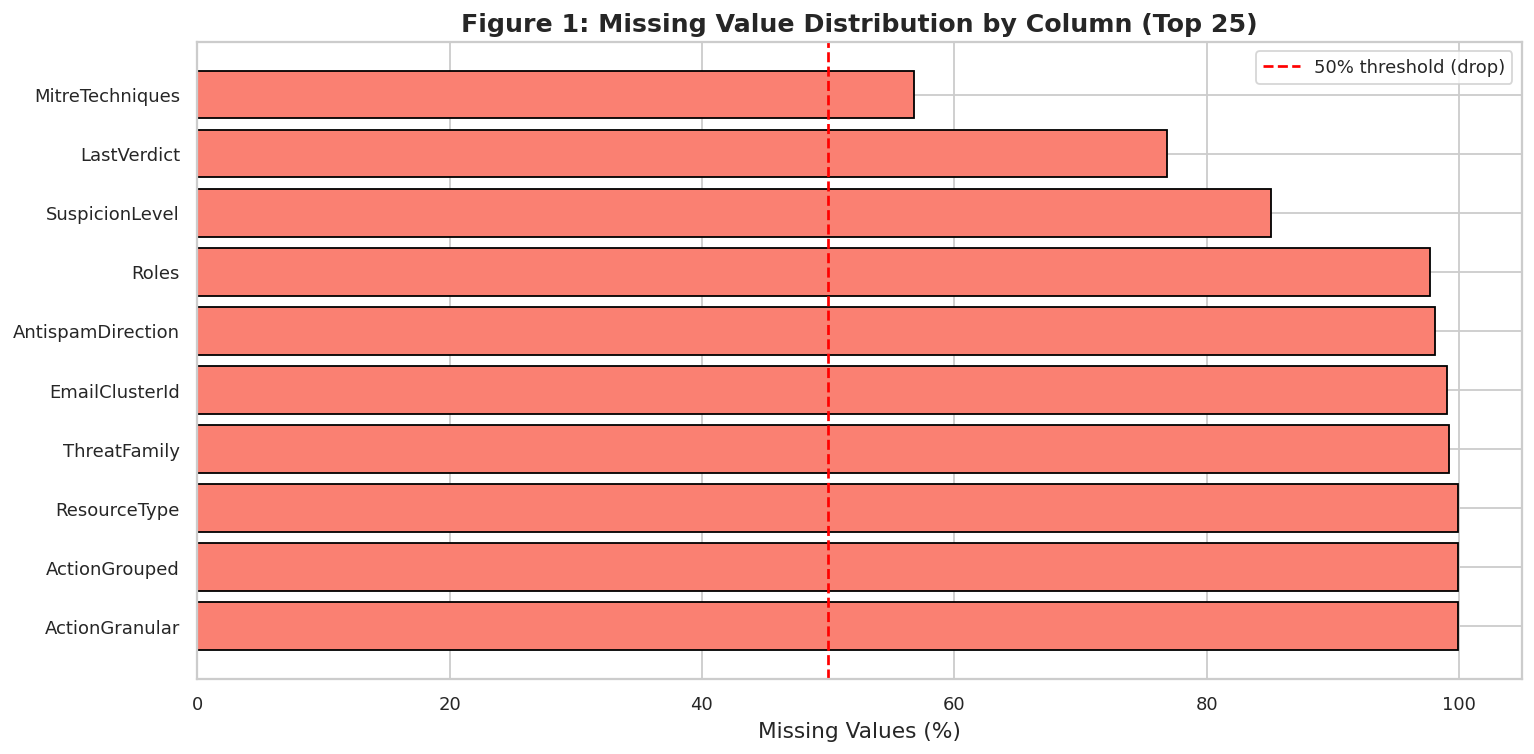

Figure 1 saved.


In [ ]:
# MISSING VALUE ANALYSIS
# Missing data is a critical challenge in cybersecurity datasets as incomplete
# incident logs are common in real SOC environments. identify and quantify
# missing values before deciding on appropriate imputation strategies.

print("=" * 65)
print("SECTION 2: MISSING VALUE ANALYSIS")
print("=" * 65)

# ── Calculate missing percentage per column
missing_count = train_df.isnull().sum()
missing_pct   = (missing_count / len(train_df) * 100).round(2)
missing_df    = pd.DataFrame({
    "Missing Count"  : missing_count,
    "Missing (%)"    : missing_pct
}).sort_values("Missing (%)", ascending=False)

# Only show columns that have at least one missing value
missing_df = missing_df[missing_df["Missing Count"] > 0]
print(f"\n  Columns with missing values: {len(missing_df)}")
display(missing_df.head(20))

# ── Classify columns by missingness threshold
# Columns with >50% missing values offer little predictive value and will be dropped.
# Columns with <50% missing will be imputed using mode (categorical) or median (numerical).
high_missing = missing_df[missing_df["Missing (%)"] > 50].index.tolist()
low_missing  = missing_df[missing_df["Missing (%)"] <= 50].index.tolist()

print(f"\n Columns to DROP (>50% missing)    : {len(high_missing)}")
print(f" Columns to IMPUTE (≤50% missing)  : {len(low_missing)}")

# ── Visualise missing values
fig, ax = plt.subplots(figsize=(12, 6))
missing_plot = missing_df[missing_df["Missing (%)"] > 0].head(25)
bars = ax.barh(missing_plot.index, missing_plot["Missing (%)"], color="salmon", edgecolor="black")
ax.axvline(x=50, color="red", linestyle="--", linewidth=1.5, label="50% threshold (drop)")
ax.set_xlabel("Missing Values (%)")
ax.set_title("Figure 1: Missing Value Distribution by Column (Top 25)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("fig1_missing_values.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 1 saved.")

SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)


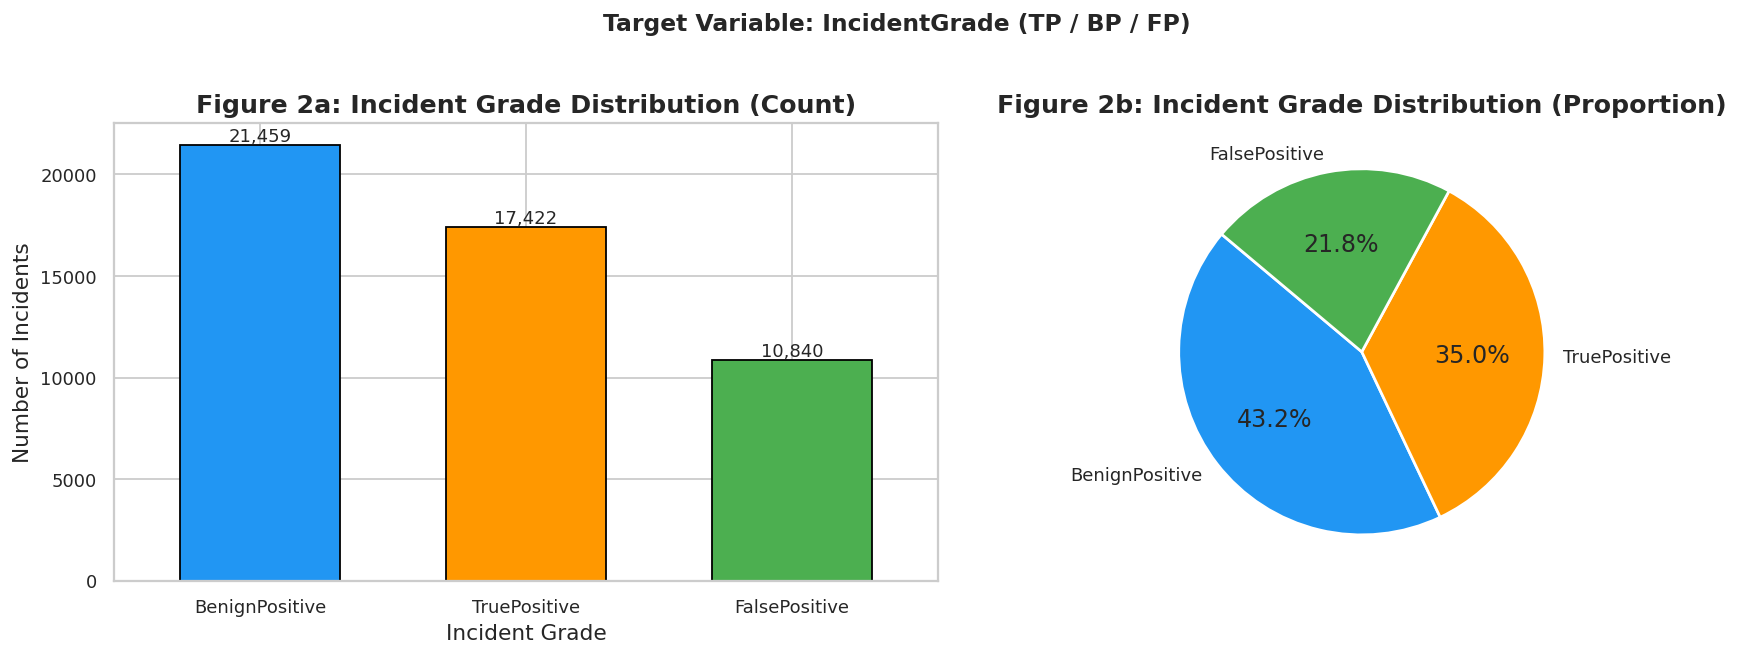

Figure 2 saved.


In [ ]:
#EXPLORATORY DATA ANALYSIS (EDA) — TARGET VARIABLE
# Understanding the distribution of the target variable is the first step in
# any classification study. Class imbalance, if present, must be identified
# early as it directly affects model selection and evaluation strategy.
print("=" * 65)
print("SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 65)

# ── Figure 2: Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ["#2196F3", "#FF9800", "#4CAF50"]
grade_counts.plot(kind="bar", ax=axes[0], color=colors, edgecolor="black", width=0.6)
axes[0].set_title("Figure 2a: Incident Grade Distribution (Count)", fontweight="bold")
axes[0].set_xlabel("Incident Grade")
axes[0].set_ylabel("Number of Incidents")
axes[0].tick_params(axis="x", rotation=0)
for bar in axes[0].patches:
    axes[0].annotate(f"{int(bar.get_height()):,}",
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha="center", va="bottom", fontsize=10)

# Pie chart
axes[1].pie(grade_counts, labels=grade_counts.index, autopct="%1.1f%%",
            colors=colors, startangle=140, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("Figure 2b: Incident Grade Distribution (Proportion)", fontweight="bold")

plt.suptitle("Target Variable: IncidentGrade (TP / BP / FP)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig2_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 2 saved.")

 Categorical feature columns identified: 13
['Timestamp', 'Category', 'MitreTechniques', 'ActionGrouped', 'ActionGranular', 'EntityType', 'EvidenceRole', 'ThreatFamily', 'ResourceType', 'Roles', 'AntispamDirection', 'SuspicionLevel', 'LastVerdict']


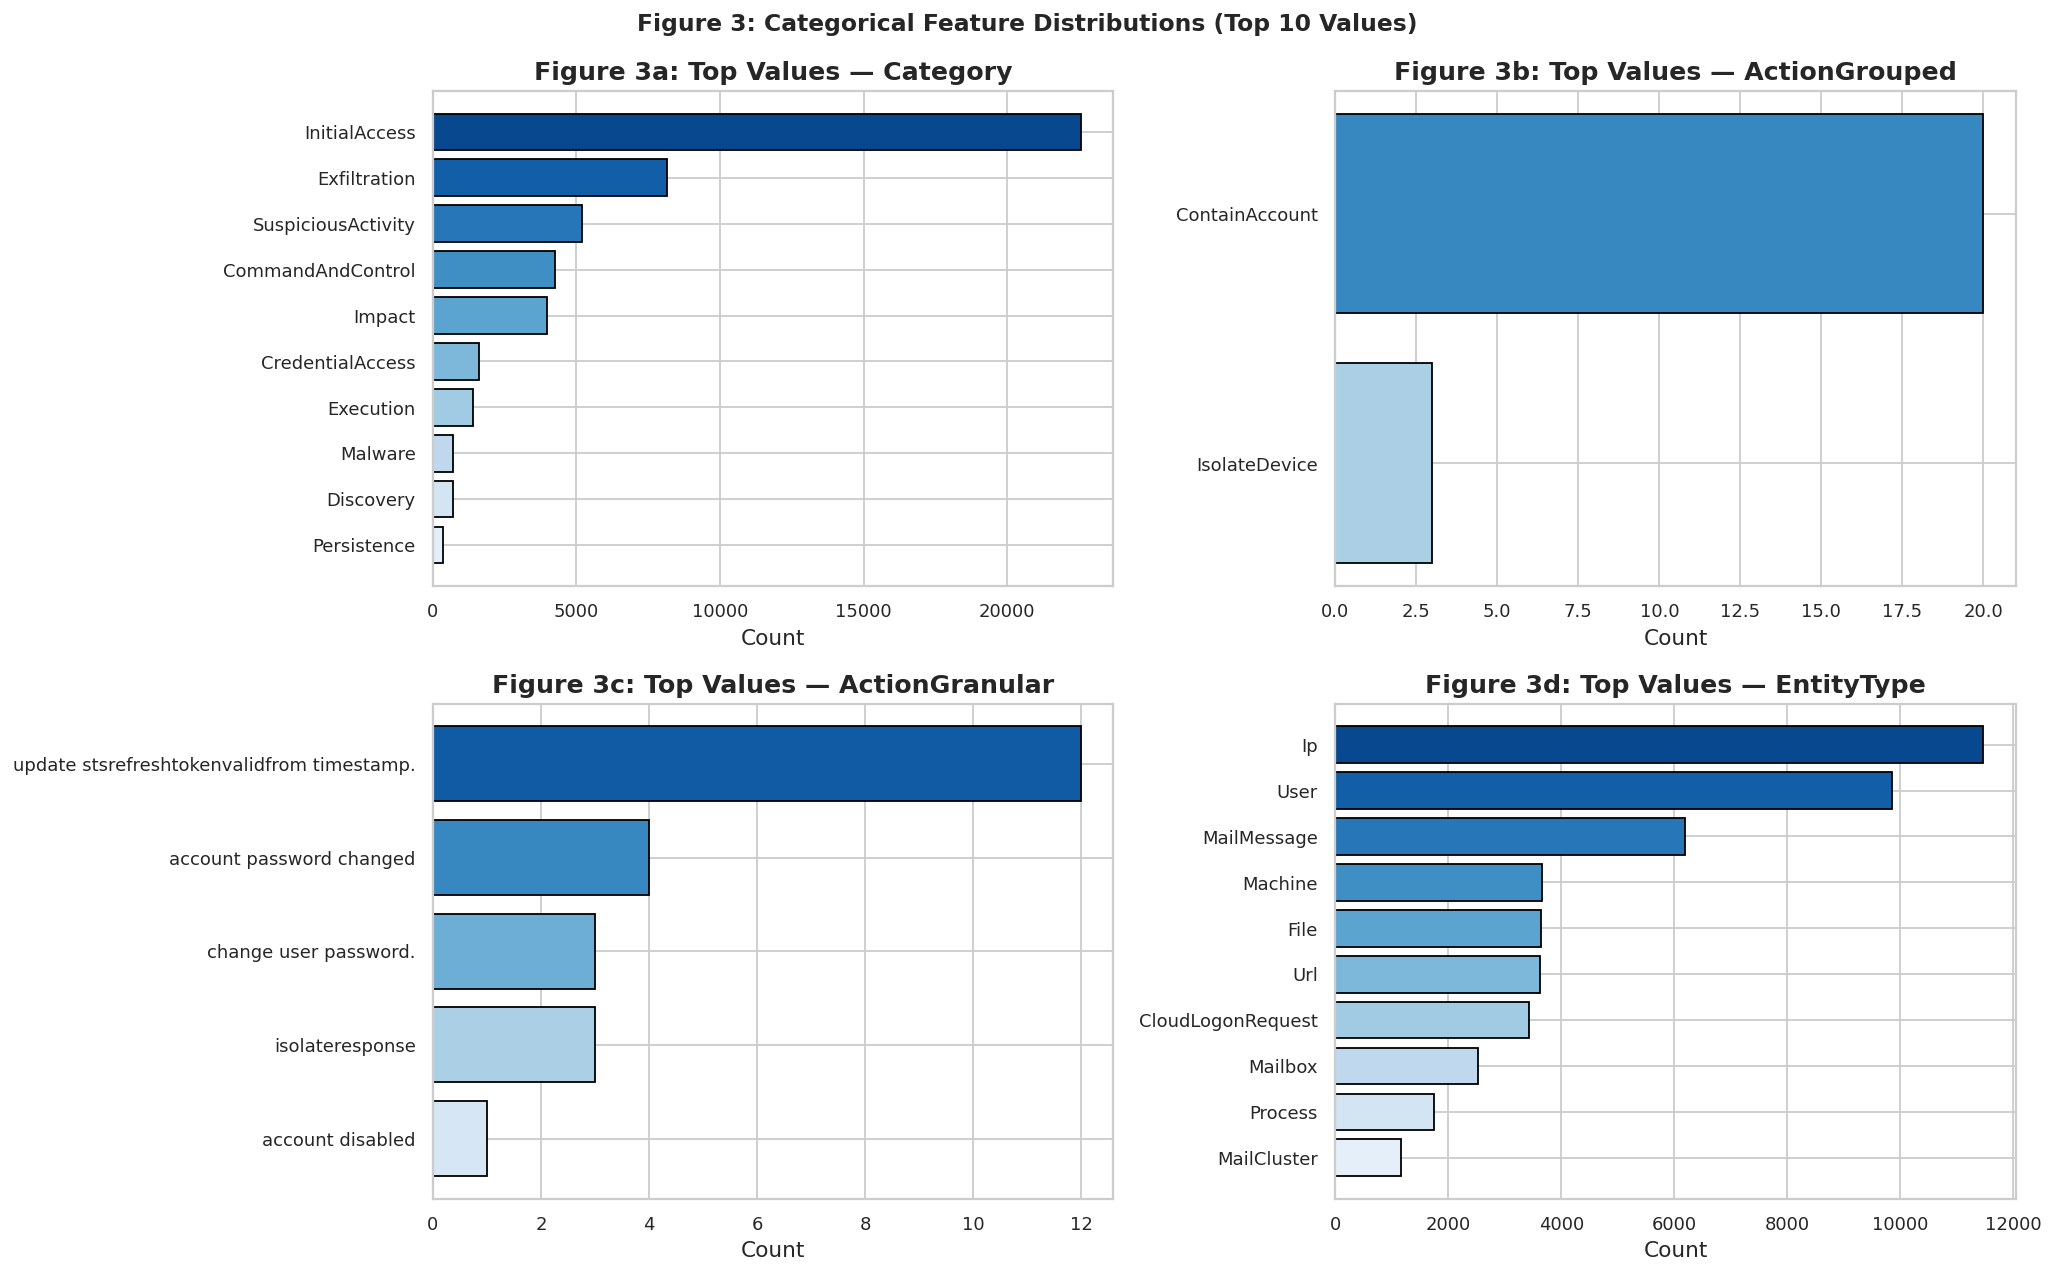

Figure 3 saved.


In [ ]:
#  EDA: CATEGORICAL FEATURE ANALYSIS
#  examine the key categorical features in the dataset to understand the
# distribution of attack categories, detector types, and alert titles.
# This informs feature selection and engineering decisions.

# Identify categorical columns (object dtype, excluding target and IDs)
id_cols = ["Id", "IncidentId", "AlertId", "DetectorId", "OrgId"]
cat_cols = [c for c in train_df.select_dtypes(include="object").columns
            if c not in id_cols + ["IncidentGrade"]]

print(f" Categorical feature columns identified: {len(cat_cols)}")
print(cat_cols)

# ── Figure 3: Top categorical feature value counts
# Select up to 4 categorical columns with manageable cardinality for visualisation
plot_cats = [c for c in cat_cols if train_df[c].nunique() <= 30][:4]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(plot_cats):
    top_vals = train_df[col].value_counts().head(10)
    axes[i].barh(top_vals.index.astype(str), top_vals.values,
                 color=sns.color_palette("Blues_r", len(top_vals)), edgecolor="black")
    axes[i].set_title(f"Figure 3{chr(97+i)}: Top Values — {col}", fontweight="bold")
    axes[i].set_xlabel("Count")
    axes[i].invert_yaxis()

# Hide unused subplots
for j in range(len(plot_cats), 4):
    axes[j].set_visible(False)

plt.suptitle("Figure 3: Categorical Feature Distributions (Top 10 Values)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig3_categorical_eda.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 3 saved.")

 Numerical feature columns identified: 26
['AlertTitle', 'DeviceId', 'Sha256', 'IpAddress', 'Url', 'AccountSid', 'AccountUpn', 'AccountObjectId', 'AccountName', 'DeviceName', 'NetworkMessageId', 'EmailClusterId', 'RegistryKey', 'RegistryValueName', 'RegistryValueData', 'ApplicationId', 'ApplicationName', 'OAuthApplicationId', 'FileName', 'FolderPath', 'ResourceIdName', 'OSFamily', 'OSVersion', 'CountryCode', 'State', 'City']


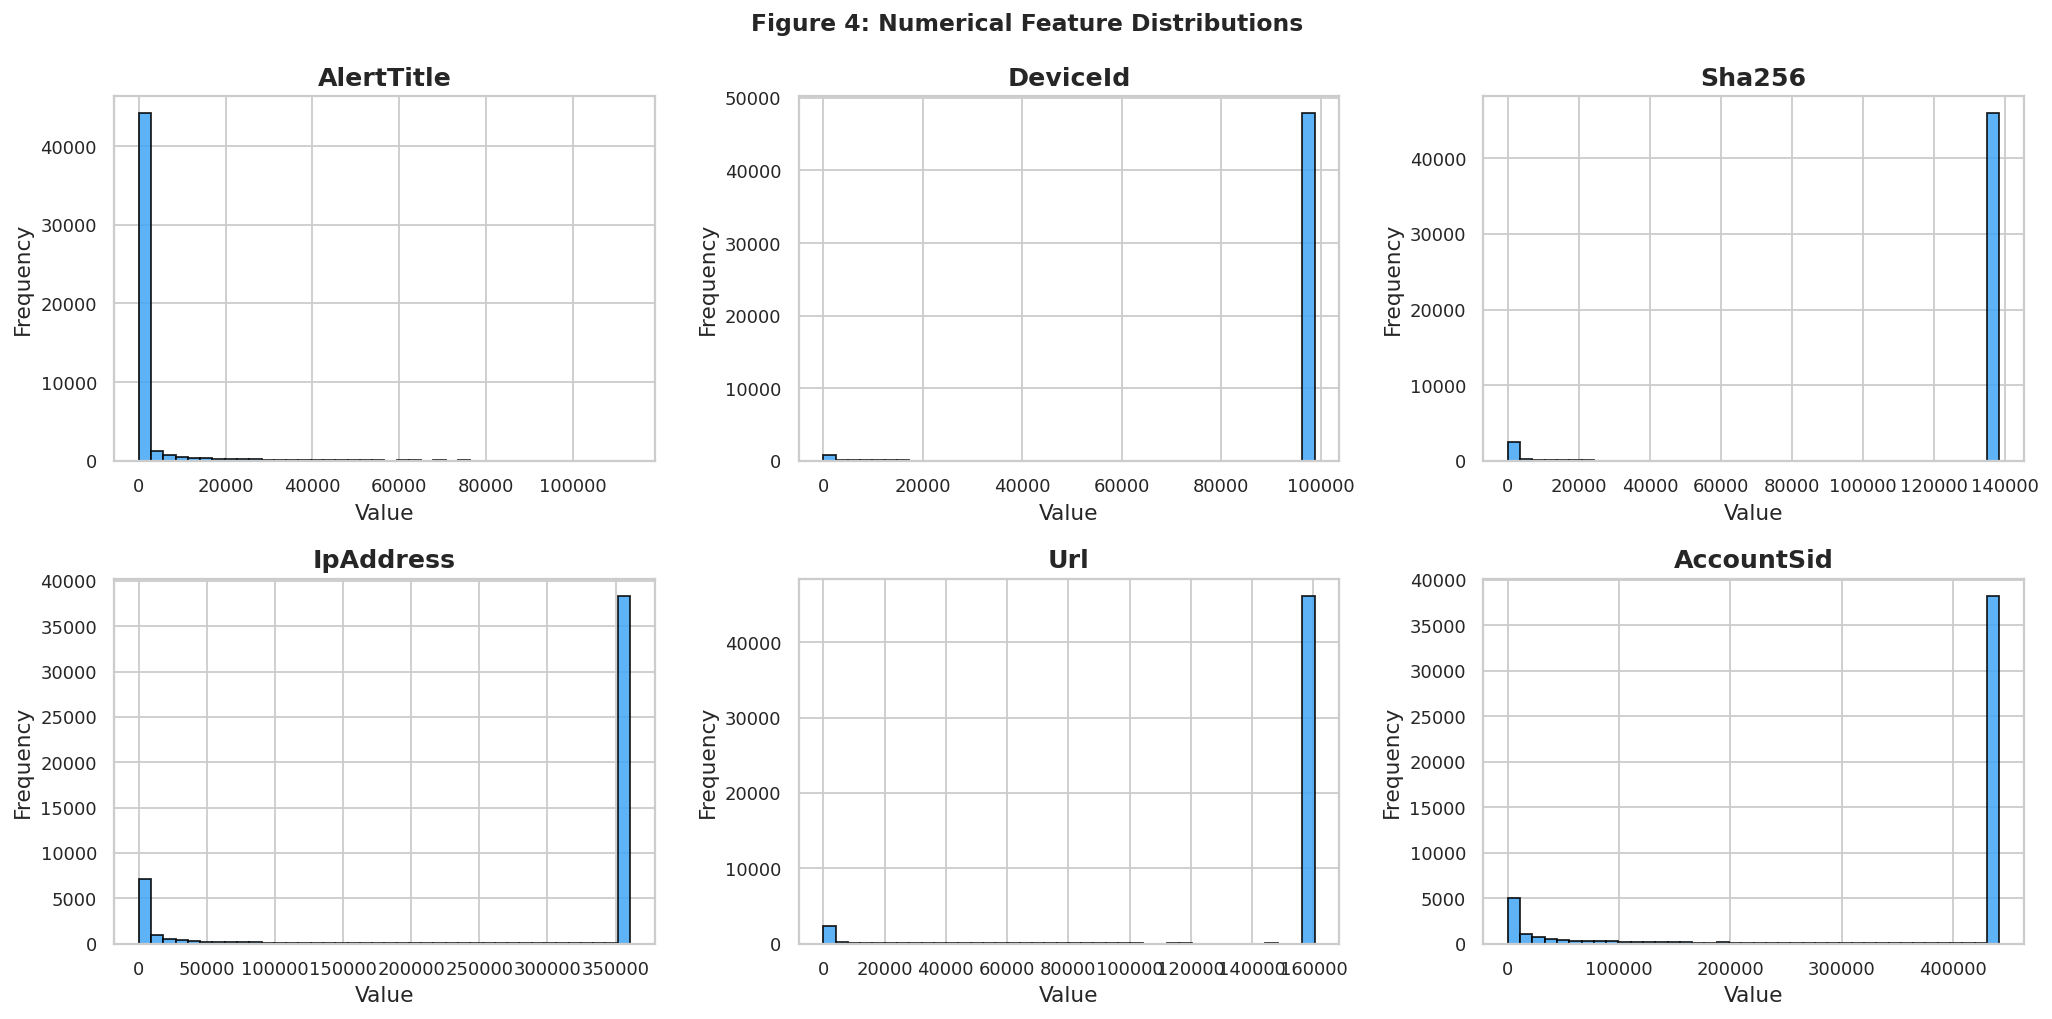

 Figure 4 saved.


In [ ]:
# EDA: NUMERICAL FEATURE ANALYSIS
# Statistical distributions of numeric features are visualised to detect
# skewness, outliers, and feature ranges — all of which influence model
# performance and preprocessing choices (e.g., scaling, log-transform).

# Identify numerical columns (excluding ID-type integers)
num_cols = [c for c in train_df.select_dtypes(include=[np.number]).columns
            if c not in id_cols]

print(f" Numerical feature columns identified: {len(num_cols)}")
print(num_cols)

if len(num_cols) > 0:
    # ── Figure 4: Distribution plots for numerical features
    n_plots = min(len(num_cols), 6)
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()

    for i, col in enumerate(num_cols[:n_plots]):
        axes[i].hist(train_df[col].dropna(), bins=40, color="#42A5F5", edgecolor="black", alpha=0.85)
        axes[i].set_title(f"{col}", fontweight="bold")
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Frequency")

    for j in range(n_plots, 6):
        axes[j].set_visible(False)

    plt.suptitle("Figure 4: Numerical Feature Distributions", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("fig4_numerical_distributions.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(" Figure 4 saved.")

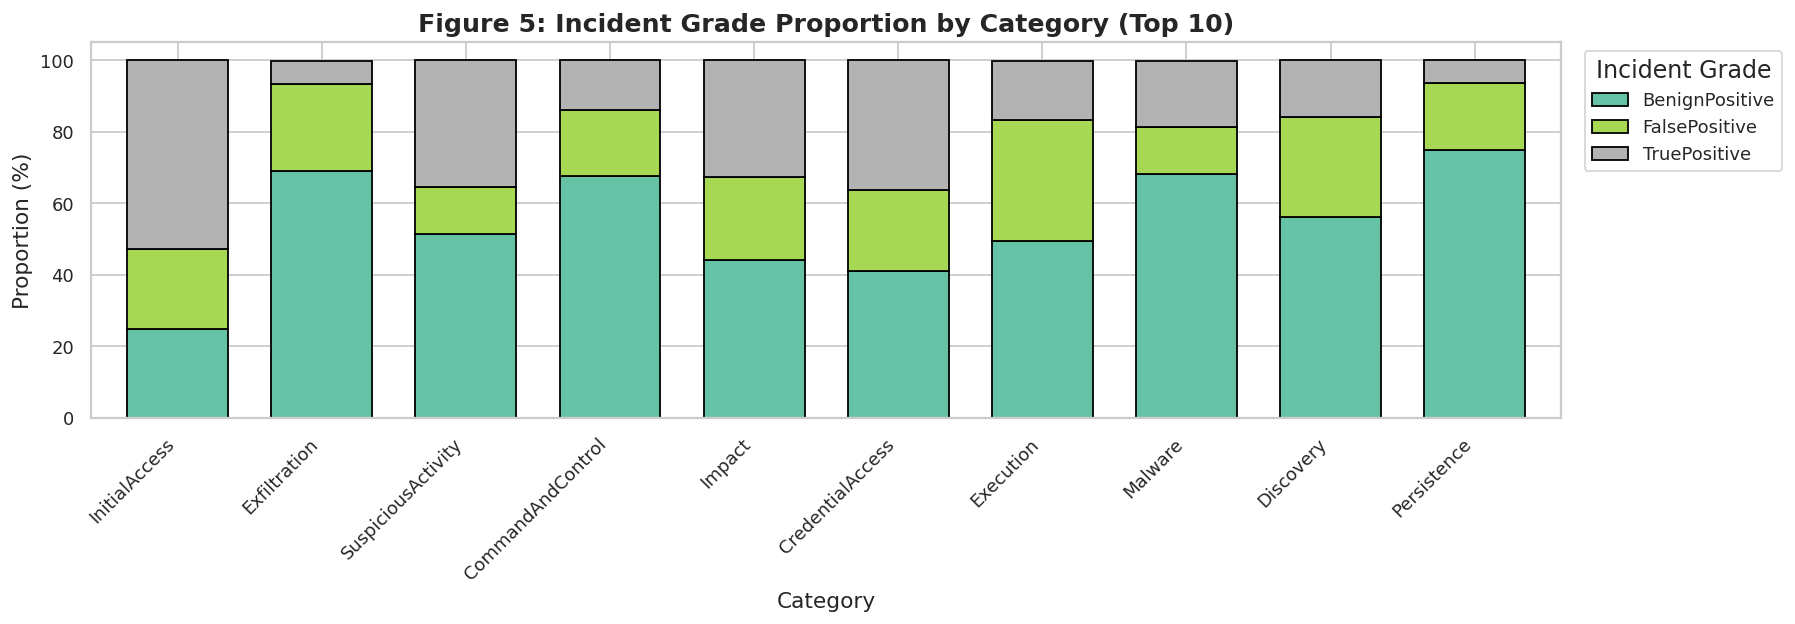

Figure 5 saved.


In [ ]:
# EDA: CATEGORY vs TARGET ANALYSIS
# Cross-tabulation between categorical features and the target variable reveals
# which categories are most associated with each incident grade (TP/BP/FP).
# This provides preliminary evidence of predictive relevance.

if len(cat_cols) > 0 and len(plot_cats) > 0:
    # ── Figure 5: Stacked bar — category vs IncidentGrade
    col = plot_cats[0]  # Use first plottable categorical feature
    ct = pd.crosstab(train_df[col], train_df["IncidentGrade"], normalize="index").mul(100).round(1)
    ct_top = ct.loc[train_df[col].value_counts().head(10).index]

    ct_top.plot(kind="bar", stacked=True, figsize=(14, 5), colormap="Set2", edgecolor="black", width=0.7)
    plt.title(f"Figure 5: Incident Grade Proportion by {col} (Top 10)", fontweight="bold")
    plt.xlabel(col)
    plt.ylabel("Proportion (%)")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Incident Grade", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig("fig5_category_vs_target.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure 5 saved.")

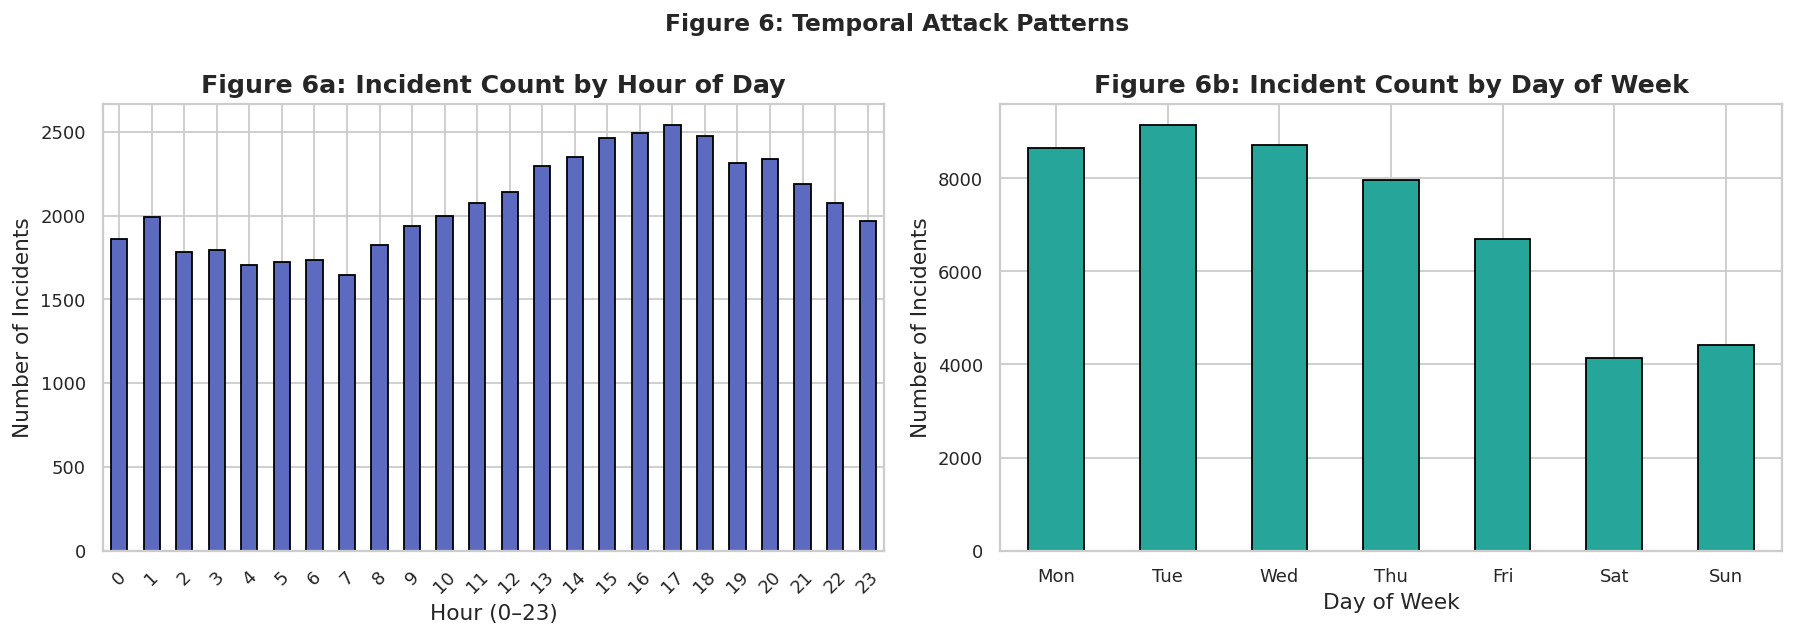

Figure 6 saved.


In [ ]:
# EDA: TEMPORAL FEATURE ANALYSIS
# The Timestamp column captures when each alert was generated. Decomposing it
# into Hour, Day, and Month enables analysis of temporal attack patterns —
# a key factor in cybersecurity incident prediction.

# ── Parse Timestamp and extract temporal components
if "Timestamp" in train_df.columns:
    train_df["Timestamp"] = pd.to_datetime(train_df["Timestamp"], errors="coerce")
    train_df["Hour"]      = train_df["Timestamp"].dt.hour
    train_df["DayOfWeek"] = train_df["Timestamp"].dt.dayofweek   # 0=Monday, 6=Sunday
    train_df["Month"]     = train_df["Timestamp"].dt.month

    # ── Figure 6: Incident frequency by hour and day
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Hourly distribution
    train_df.groupby("Hour")["IncidentGrade"].count().plot(
        kind="bar", ax=axes[0], color="#5C6BC0", edgecolor="black")
    axes[0].set_title("Figure 6a: Incident Count by Hour of Day", fontweight="bold")
    axes[0].set_xlabel("Hour (0–23)")
    axes[0].set_ylabel("Number of Incidents")
    axes[0].tick_params(axis="x", rotation=45)

    # Day of week distribution
    day_map = {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}
    train_df["DayName"] = train_df["DayOfWeek"].map(day_map)
    day_order = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
    train_df.groupby("DayName")["IncidentGrade"].count().reindex(day_order).plot(
        kind="bar", ax=axes[1], color="#26A69A", edgecolor="black")
    axes[1].set_title("Figure 6b: Incident Count by Day of Week", fontweight="bold")
    axes[1].set_xlabel("Day of Week")
    axes[1].set_ylabel("Number of Incidents")
    axes[1].tick_params(axis="x", rotation=0)

    plt.suptitle("Figure 6: Temporal Attack Patterns", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("fig6_temporal_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure 6 saved.")
else:
    print("Timestamp column not found — skipping temporal analysis.")

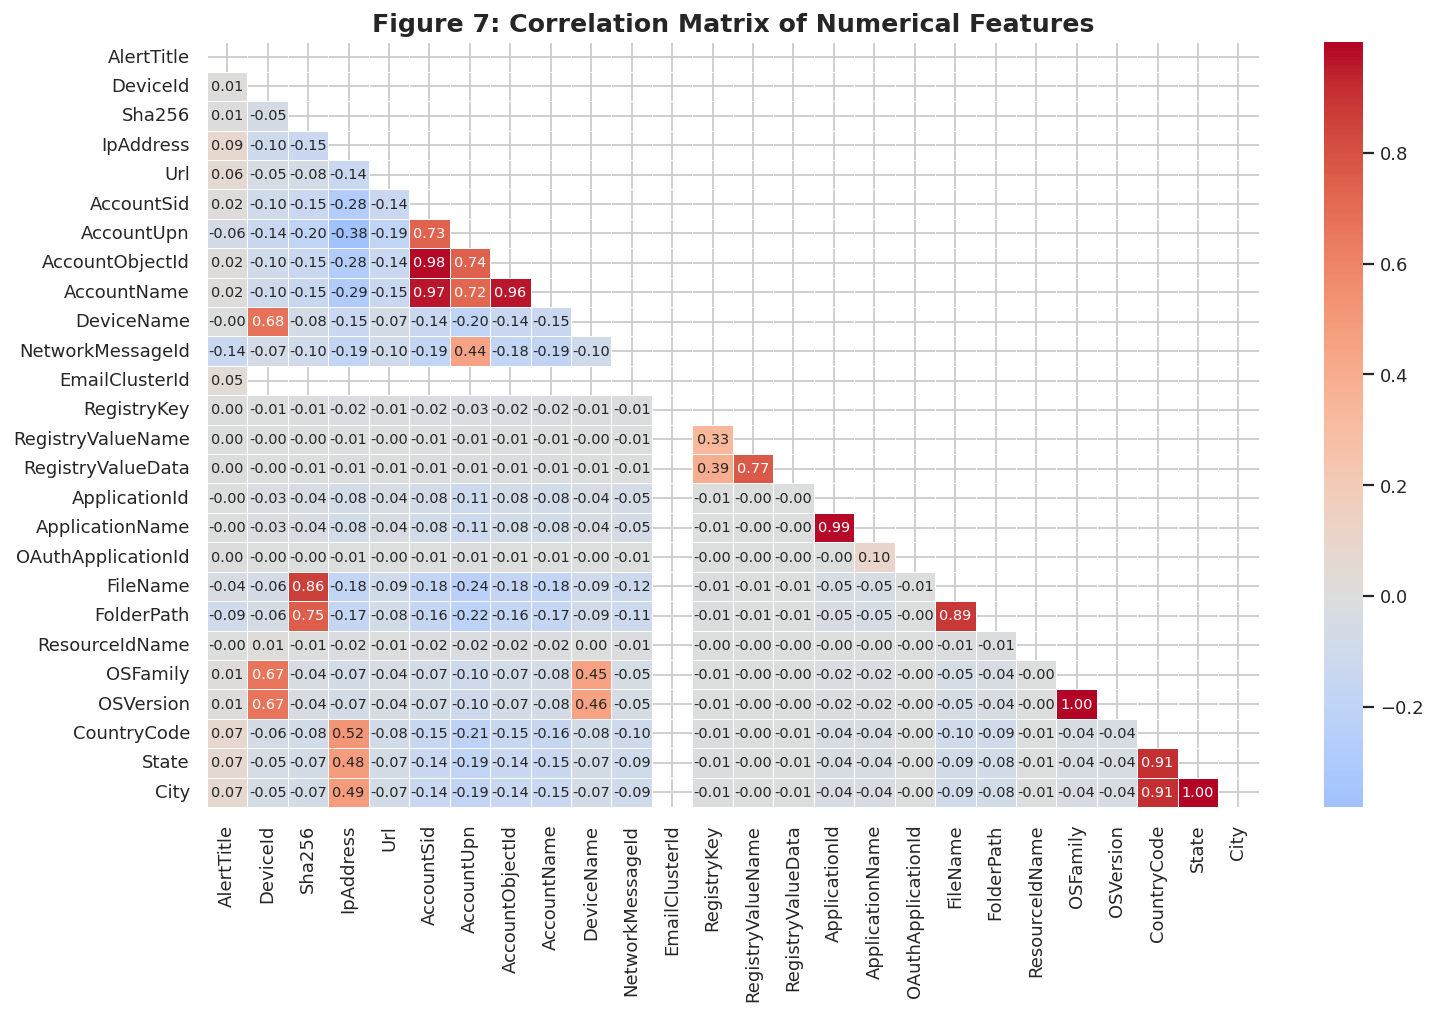

Figure 7 saved.

Highly correlated feature pairs (|r| > 0.90):
  AccountObjectId  ↔  AccountSid  :  r = 0.985
  AccountName  ↔  AccountSid  :  r = 0.966
  AccountName  ↔  AccountObjectId  :  r = 0.958
  ApplicationName  ↔  ApplicationId  :  r = 0.985
  OSVersion  ↔  OSFamily  :  r = 0.999
  State  ↔  CountryCode  :  r = 0.913
  City  ↔  CountryCode  :  r = 0.909
  City  ↔  State  :  r = 0.996


In [ ]:
# EDA: CORRELATION ANALYSIS
# A correlation heatmap of numerical features identifies multicollinearity.
# Highly correlated features (r > 0.90) may be redundant and candidates for
# removal to reduce dimensionality and prevent overfitting.

num_data = train_df[num_cols].dropna(axis=1, how="all")

if num_data.shape[1] > 1:
    corr_matrix = num_data.corr()

    fig, ax = plt.subplots(figsize=(12, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show lower triangle only
    sns.heatmap(
        corr_matrix, mask=mask, annot=True, fmt=".2f",
        cmap="coolwarm", center=0, linewidths=0.5,
        annot_kws={"size": 8}, ax=ax
    )
    ax.set_title("Figure 7: Correlation Matrix of Numerical Features", fontweight="bold")
    plt.tight_layout()
    plt.savefig("fig7_correlation_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure 7 saved.")

    # Flag highly correlated pairs for potential removal
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > 0.90:
                high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j],
                                        round(corr_matrix.iloc[i, j], 3)))
    if high_corr_pairs:
        print(f"\nHighly correlated feature pairs (|r| > 0.90):")
        for pair in high_corr_pairs:
            print(f"  {pair[0]}  ↔  {pair[1]}  :  r = {pair[2]}")
    else:
        print("\nNo highly correlated feature pairs detected (|r| > 0.90).")
else:
    print(" Insufficient numerical columns for correlation analysis.")

In [ ]:
# DATA PREPROCESSING: STEP 1 — DROP HIGH-MISSING AND ID COLUMNS
# Columns with >50% missing values are dropped as they introduce excessive
# noise and cannot be reliably imputed. ID-type columns are non-informative
# for prediction and are excluded from the feature matrix.

print("=" * 65)
print("SECTION 4: DATA PREPROCESSING")
print("=" * 65)

def preprocess_dataframe(df, high_missing_cols, id_cols):
    """
    Apply preprocessing steps to a given dataframe.
    Designed to apply identical transformations to both train and test sets.

    Parameters:
        df              : pd.DataFrame — input dataframe
        high_missing_cols : list — columns to drop due to >50% missingness
        id_cols         : list — identifier columns to remove

    Returns:
        df              : pd.DataFrame — cleaned dataframe
    """
    # Drop high-missing columns
    cols_to_drop = [c for c in high_missing_cols + id_cols if c in df.columns]
    df = df.drop(columns=cols_to_drop)
    print(f"  Dropped {len(cols_to_drop)} columns (IDs + high missing).")

    # Drop Timestamp — replaced by engineered Hour/DayOfWeek/Month features
    if "Timestamp" in df.columns:
        df = df.drop(columns=["Timestamp"])

    # Drop DayName if present (string version of DayOfWeek, redundant)
    if "DayName" in df.columns:
        df = df.drop(columns=["DayName"])

    return df

# Apply preprocessing
train_df = preprocess_dataframe(train_df, high_missing, id_cols)
test_df  = preprocess_dataframe(test_df,  high_missing, id_cols)

print(f"\n Train shape after column removal : {train_df.shape}")
print(f" Test shape after column removal  : {test_df.shape}")

SECTION 4: DATA PREPROCESSING
  Dropped 15 columns (IDs + high missing).
  Dropped 15 columns (IDs + high missing).

 Train shape after column removal : (49721, 32)
 Test shape after column removal  : (50000, 30)


In [ ]:
# DATA PREPROCESSING: STEP 2 — IMPUTE REMAINING MISSING VALUES
# For remaining columns with missing values:
#   - Categorical: mode imputation (most frequent value)
#   - Numerical  : median imputation (robust to outliers)
# This approach is standard in supervised ML pipelines (Géron, 2022).

def impute_missing(df):
    """Impute missing values: mode for categoricals, median for numericals."""
    cat_cols_local = df.select_dtypes(include="object").columns.tolist()
    num_cols_local = df.select_dtypes(include=[np.number]).columns.tolist()

    # Categorical — mode imputation
    for col in cat_cols_local:
        if df[col].isnull().sum() > 0:
            mode_val = df[col].mode()[0]
            df[col] = df[col].fillna(mode_val)

    # Numerical — median imputation
    for col in num_cols_local:
        if df[col].isnull().sum() > 0:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)

    return df

train_df = impute_missing(train_df)
test_df  = impute_missing(test_df)

# Verify no missing values remain
remaining_nulls_train = train_df.isnull().sum().sum()
remaining_nulls_test  = test_df.isnull().sum().sum()
print(f"Imputation complete.")
print(f"   Remaining nulls in train : {remaining_nulls_train}")
print(f"   Remaining nulls in test  : {remaining_nulls_test}")

Imputation complete.
   Remaining nulls in train : 0
   Remaining nulls in test  : 0


In [ ]:
# DATA PREPROCESSING: STEP 3 — ENCODE CATEGORICAL VARIABLES
# Machine learning algorithms require numerical inputs.  apply Label Encoding
# to categorical features. For high-cardinality features this is more memory-
# efficient than One-Hot Encoding (OHE). The same encoder is fitted on the
# training set and applied to the test set to prevent data leakage.

# ── Encode target variable
# IncidentGrade: TP=2, BP=0, FP=1 (alphabetical by default LabelEncoder)
target_encoder = LabelEncoder()
train_df["IncidentGrade_enc"] = target_encoder.fit_transform(train_df["IncidentGrade"])

# Store mapping for reporting
grade_mapping = dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))
print(f"Target variable encoding map : {grade_mapping}")

# ── Encode categorical feature columns
cat_feat_cols = [c for c in train_df.select_dtypes(include="object").columns
                 if c != "IncidentGrade"]

label_encoders = {}  # Store encoders keyed by column name for test-set reuse

for col in cat_feat_cols:
    le = LabelEncoder()
    # Fit on combined unique values from both train and test to avoid unseen label errors
    combined_vals = pd.concat([train_df[col], test_df[col]]).astype(str).unique()
    le.fit(combined_vals)

    train_df[col] = le.transform(train_df[col].astype(str))
    test_df[col]  = le.transform(test_df[col].astype(str))

    label_encoders[col] = le

print(f" Label encoding applied to {len(cat_feat_cols)} categorical columns.")

Target variable encoding map : {'BenignPositive': np.int64(0), 'FalsePositive': np.int64(1), 'TruePositive': np.int64(2)}
 Label encoding applied to 3 categorical columns.


In [ ]:
# DATA PREPROCESSING: STEP 4 — FEATURE / TARGET SPLIT AND SCALING
#  separate features (X) from the target (y), then apply StandardScaler
# to numerical features. Scaling is critical for distance-based algorithms
# Note: Tree-based models (RF, XGBoost, DT) are scale-invariant, but scaling
# all features ensures a consistent pipeline across all five models.

# ── Define feature matrix and target vector
DROP_FOR_X = ["IncidentGrade", "IncidentGrade_enc"]

X = train_df.drop(columns=[c for c in DROP_FOR_X if c in train_df.columns])
y = train_df["IncidentGrade_enc"]

# ── Remove target-related columns from test set
X_holdout = test_df.drop(columns=[c for c in DROP_FOR_X if c in test_df.columns], errors="ignore")

# Align columns — ensure test set has same features as train
X_holdout = X_holdout.reindex(columns=X.columns, fill_value=0)

print(f"Feature matrix X shape       : {X.shape}")
print(f" Target vector y shape        : {y.shape}")
print(f" Holdout test set shape       : {X_holdout.shape}")
print(f"\n Class distribution in y:")
for cls, count in zip(target_encoder.classes_, np.bincount(y)):
    print(f"   {cls} ({grade_mapping[cls]}) : {count:,} samples")

# ── Train / Validation split (80:20)
# Stratified split preserves class ratios in both partitions
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"\n Train/Validation split (80:20):")
print(f"   Training set   : {X_train.shape[0]:,} rows")
print(f"   Validation set : {X_val.shape[0]:,} rows")

# ── Feature scaling ───────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # Fit ONLY on training data
X_val_sc   = scaler.transform(X_val)         # Apply same transform to validation
X_hout_sc  = scaler.transform(X_holdout)     # Apply same transform to holdout

print("\n StandardScaler applied (fitted on training set only — no data leakage).")

Feature matrix X shape       : (49721, 31)
 Target vector y shape        : (49721,)
 Holdout test set shape       : (50000, 31)

 Class distribution in y:
   BenignPositive (0) : 21,459 samples
   FalsePositive (1) : 10,840 samples
   TruePositive (2) : 17,422 samples

 Train/Validation split (80:20):
   Training set   : 39,776 rows
   Validation set : 9,945 rows

 StandardScaler applied (fitted on training set only — no data leakage).


SECTION 5: CLASS IMBALANCE HANDLING (SMOTE)

Before SMOTE — Training class distribution:
   BenignPositive : 17,167
   FalsePositive : 8,672
   TruePositive : 13,937

After SMOTE — Training class distribution:
   BenignPositive : 17,167
   FalsePositive : 17,167
   TruePositive : 17,167

SMOTE complete. Resampled training set shape: (51501, 31)


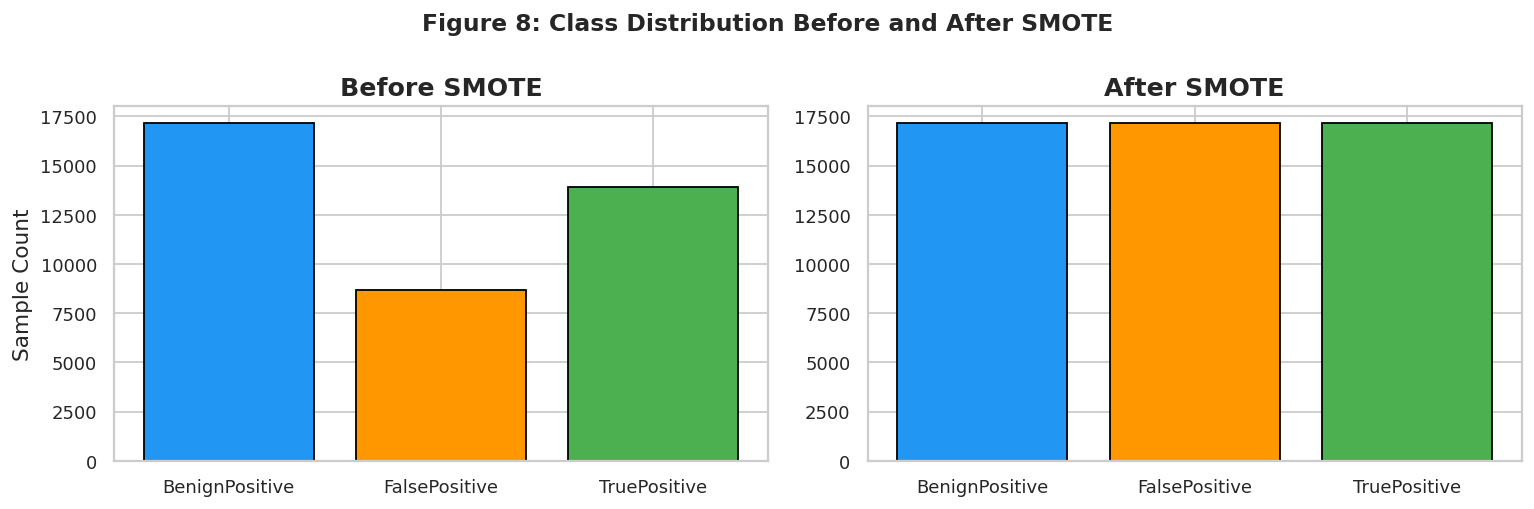

Figure 8 saved.


In [ ]:
# CLASS IMBALANCE HANDLING WITH SMOTE
# Cybersecurity datasets often exhibit class imbalance (Sarker, 2023).
# apply SMOTE (Synthetic Minority Over-sampling Technique) to the training
# set ONLY — not validation or test — to avoid information leakage.
# SMOTE generates synthetic samples for minority classes by interpolating
# between existing samples in feature space (Chawla et al., 2002).

print("=" * 65)
print("SECTION 5: CLASS IMBALANCE HANDLING (SMOTE)")
print("=" * 65)

print(f"\nBefore SMOTE — Training class distribution:")
for cls, count in zip(target_encoder.classes_, np.bincount(y_train)):
    print(f"   {cls} : {count:,}")

# Apply SMOTE to scaled training data
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train_sc, y_train)

print(f"\nAfter SMOTE — Training class distribution:")
for cls, count in zip(target_encoder.classes_, np.bincount(y_train_res)):
    print(f"   {cls} : {count:,}")

print(f"\nSMOTE complete. Resampled training set shape: {X_train_res.shape}")

# ── Figure 8: Before/after SMOTE comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

before = Counter(y_train)
after  = Counter(y_train_res)
labels = [target_encoder.classes_[k] for k in sorted(before.keys())]

axes[0].bar(labels, [before[k] for k in sorted(before.keys())],
            color=["#2196F3","#FF9800","#4CAF50"], edgecolor="black")
axes[0].set_title("Before SMOTE", fontweight="bold")
axes[0].set_ylabel("Sample Count")

axes[1].bar(labels, [after[k] for k in sorted(after.keys())],
            color=["#2196F3","#FF9800","#4CAF50"], edgecolor="black")
axes[1].set_title("After SMOTE", fontweight="bold")

plt.suptitle("Figure 8: Class Distribution Before and After SMOTE", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig8_smote_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 8 saved.")

In [ ]:
# HELPER FUNCTIONS FOR MODEL EVALUATION
# Centralised evaluation functions ensure consistent metric computation across
# all five models. Metrics reported: Accuracy, Precision (macro), Recall (macro),
# F1-score (macro), and ROC-AUC (OvR macro) — as specified in the proposal.
# Macro-averaging is used because classes are of equal conceptual importance
# regardless of their frequency (Sokolova & Lapalme, 2009).

def evaluate_model(name, model, X_tr, y_tr, X_vl, y_vl, results_list):
    """
    Train a model, generate predictions, compute all evaluation metrics,
    and append results to a shared results list.

    Parameters:
        name         : str — model name for reporting
        model        : sklearn-compatible estimator
        X_tr, y_tr   : training features and labels
        X_vl, y_vl   : validation features and labels
        results_list : list — shared container to collect all model results

    Returns:
        model        : fitted model object
        y_pred       : array of validation predictions
        y_prob       : array of predicted probabilities (for ROC-AUC)
    """
    start = time.time()
    model.fit(X_tr, y_tr)
    elapsed = round(time.time() - start, 2)

    # Predictions
    y_pred = model.predict(X_vl)

    # Predicted probabilities (needed for ROC-AUC)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_vl)
    else:
        # SVM with probability=True must be set at instantiation
        y_prob = None

    # Compute metrics
    acc  = accuracy_score(y_vl, y_pred)
    prec = precision_score(y_vl, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_vl, y_pred, average="macro", zero_division=0)
    f1   = f1_score(y_vl, y_pred, average="macro", zero_division=0)
    roc  = roc_auc_score(y_vl, y_prob, multi_class="ovr", average="macro") if y_prob is not None else np.nan

    results_list.append({
        "Model"         : name,
        "Accuracy"      : round(acc,  4),
        "Precision"     : round(prec, 4),
        "Recall"        : round(rec,  4),
        "F1-Score"      : round(f1,   4),
        "ROC-AUC"       : round(roc,  4) if not np.isnan(roc) else "N/A",
        "Training Time" : f"{elapsed}s"
    })

    print(f"\n{'─'*55}")
    print(f"  Model         : {name}")
    print(f"  Accuracy      : {acc:.4f}")
    print(f"  Precision     : {prec:.4f}  (macro)")
    print(f"  Recall        : {rec:.4f}  (macro)")
    print(f"  F1-Score      : {f1:.4f}  (macro)")
    print(f"  ROC-AUC       : {roc:.4f}" if not np.isnan(roc) else "  ROC-AUC      : N/A")
    print(f"  Training Time : {elapsed}s")

    return model, y_pred, y_prob


def plot_confusion_matrix(name, y_true, y_pred, class_names, fig_num):
    """Plot a labelled confusion matrix for a given model's predictions."""
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(ax=ax, colorbar=True, cmap="Blues")
    ax.set_title(f"Figure {fig_num}: Confusion Matrix — {name}", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"fig{fig_num}_cm_{name.replace(' ','_')}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Figure {fig_num} (Confusion Matrix — {name}) saved.")

print("Evaluation helper functions defined.")

Evaluation helper functions defined.


SECTION 6: MODEL TRAINING AND EVALUATION

MODEL 1: Logistic Regression

───────────────────────────────────────────────────────
  Model         : Logistic Regression
  Accuracy      : 0.5420
  Precision     : 0.5047  (macro)
  Recall        : 0.5082  (macro)
  F1-Score      : 0.5056  (macro)
  ROC-AUC       : 0.7077
  Training Time : 2.48s

Detailed Classification Report — Logistic Regression:
                precision    recall  f1-score   support

BenignPositive       0.61      0.57      0.59      4292
 FalsePositive       0.31      0.29      0.30      2168
  TruePositive       0.59      0.66      0.62      3485

      accuracy                           0.54      9945
     macro avg       0.50      0.51      0.51      9945
  weighted avg       0.54      0.54      0.54      9945



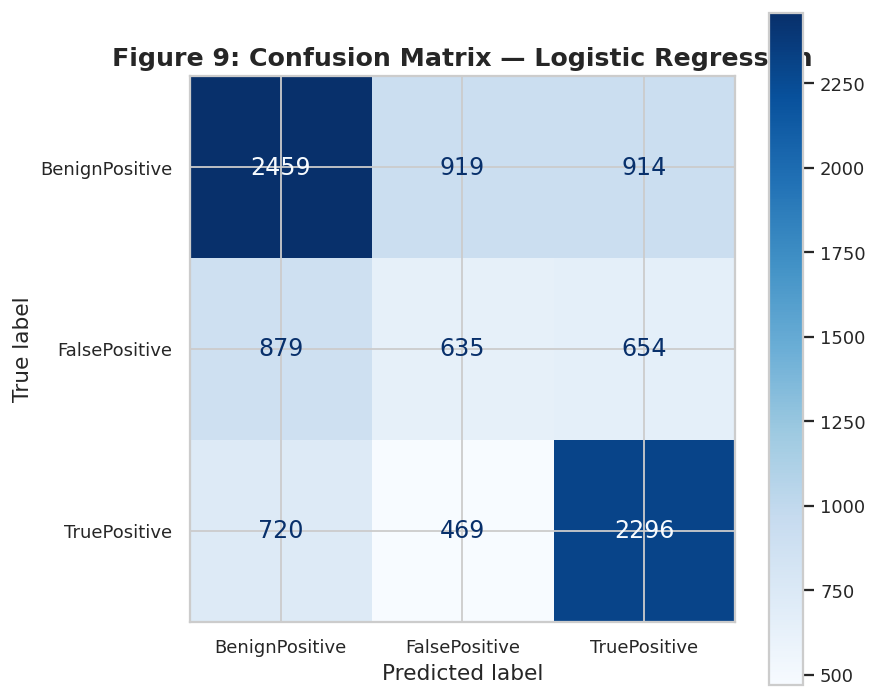

Figure 9 (Confusion Matrix — Logistic Regression) saved.


In [ ]:
# MODEL 1: LOGISTIC REGRESSION (BASELINE)
# Logistic Regression is selected as the baseline model due to its
# interpretability and simplicity. It provides a performance benchmark
# against which more complex models are compared (James et al., 2021).
# max_iter=1000 ensures convergence on this dataset size.

print("=" * 65)
print("SECTION 6: MODEL TRAINING AND EVALUATION")
print("=" * 65)

results = []  # Shared results collector for all models
class_names = target_encoder.classes_

print("\nMODEL 1: Logistic Regression")

lr_model = LogisticRegression(
    max_iter=1000,          # Sufficient iterations for convergence
    multi_class="ovr",      # One-vs-Rest strategy for multi-class
    class_weight="balanced",# Compensates for any residual class imbalance
    random_state=RANDOM_STATE,
    solver="lbfgs",         # Efficient solver for multi-class problems
    C=1.0                   # Default regularisation strength
)

lr_fitted, lr_pred, lr_prob = evaluate_model(
    "Logistic Regression", lr_model,
    X_train_res, y_train_res, X_val_sc, y_val, results
)

print(f"\nDetailed Classification Report — Logistic Regression:")
print(classification_report(y_val, lr_pred, target_names=class_names))

plot_confusion_matrix("Logistic Regression", y_val, lr_pred, class_names, fig_num=9)


 MODEL 2: Decision Tree

───────────────────────────────────────────────────────
  Model         : Decision Tree
  Accuracy      : 0.6592
  Precision     : 0.6492  (macro)
  Recall        : 0.6541  (macro)
  F1-Score      : 0.6474  (macro)
  ROC-AUC       : 0.8466
  Training Time : 0.53s

 Detailed Classification Report — Decision Tree:
                precision    recall  f1-score   support

BenignPositive       0.71      0.67      0.69      4292
 FalsePositive       0.48      0.62      0.54      2168
  TruePositive       0.76      0.67      0.71      3485

      accuracy                           0.66      9945
     macro avg       0.65      0.65      0.65      9945
  weighted avg       0.68      0.66      0.66      9945



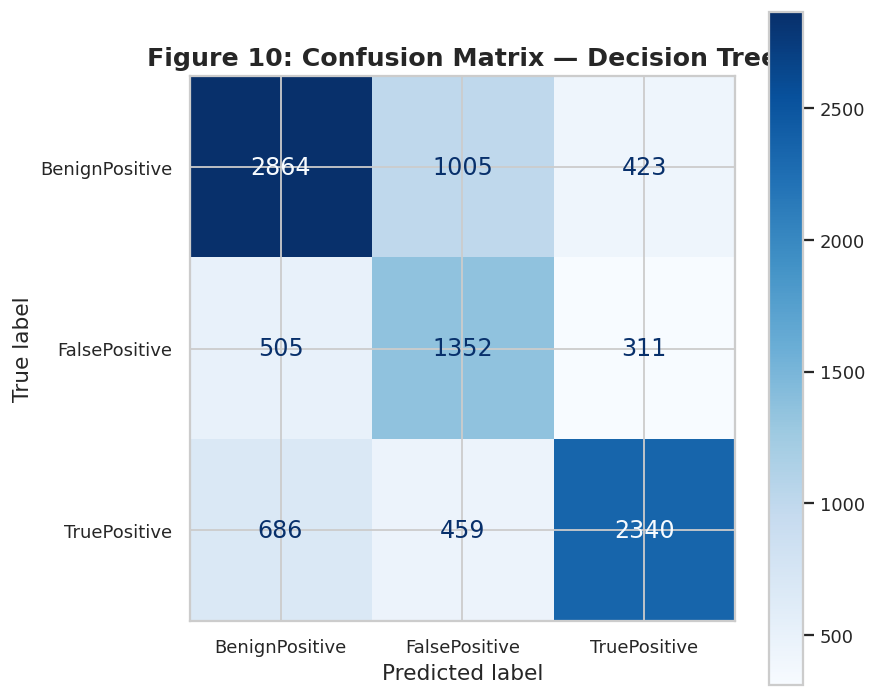

Figure 10 (Confusion Matrix — Decision Tree) saved.


In [ ]:
# MODEL 2: DECISION TREE
# Decision Trees are selected for their interpretability and ability to
# capture non-linear decision boundaries without feature scaling.
# max_depth is constrained to prevent overfitting (Breiman et al., 1984).

print("\n MODEL 2: Decision Tree")

dt_model = DecisionTreeClassifier(
    max_depth=12,            # Limit depth to control overfitting
    min_samples_split=20,    # Minimum samples required to split a node
    min_samples_leaf=10,     # Minimum samples at each leaf node
    class_weight="balanced",
    random_state=RANDOM_STATE
)

dt_fitted, dt_pred, dt_prob = evaluate_model(
    "Decision Tree", dt_model,
    X_train_res, y_train_res, X_val_sc, y_val, results
)

print(f"\n Detailed Classification Report — Decision Tree:")
print(classification_report(y_val, dt_pred, target_names=class_names))

plot_confusion_matrix("Decision Tree", y_val, dt_pred, class_names, fig_num=10)


 MODEL 3: Random Forest

───────────────────────────────────────────────────────
  Model         : Random Forest
  Accuracy      : 0.7118
  Precision     : 0.7036  (macro)
  Recall        : 0.6850  (macro)
  F1-Score      : 0.6908  (macro)
  ROC-AUC       : 0.8641
  Training Time : 12.9s

 Detailed Classification Report — Random Forest:
                precision    recall  f1-score   support

BenignPositive       0.70      0.81      0.75      4292
 FalsePositive       0.60      0.56      0.58      2168
  TruePositive       0.81      0.68      0.74      3485

      accuracy                           0.71      9945
     macro avg       0.70      0.68      0.69      9945
  weighted avg       0.72      0.71      0.71      9945



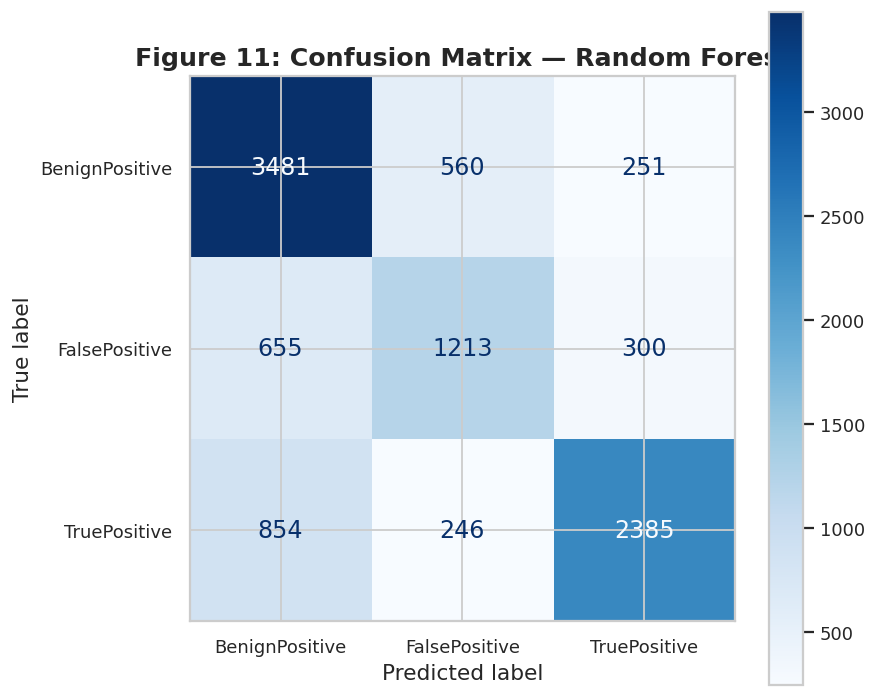

Figure 11 (Confusion Matrix — Random Forest) saved.


In [ ]:
# MODEL 3: RANDOM FOREST
# Random Forest is an ensemble of Decision Trees using bagging and random
# feature selection. It reduces variance and overfitting compared to a
# single tree, and is highly effective on structured tabular data
# (Breiman, 2001). n_estimators=200 balances performance and speed.

print("\n MODEL 3: Random Forest")

rf_model = RandomForestClassifier(
    n_estimators=200,        # Number of trees in the forest
    max_depth=15,            # Maximum depth per tree
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",     # Feature subset per split — reduces correlation between trees
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1                # Use all available CPU cores
)

rf_fitted, rf_pred, rf_prob = evaluate_model(
    "Random Forest", rf_model,
    X_train_res, y_train_res, X_val_sc, y_val, results
)

print(f"\n Detailed Classification Report — Random Forest:")
print(classification_report(y_val, rf_pred, target_names=class_names))

plot_confusion_matrix("Random Forest", y_val, rf_pred, class_names, fig_num=11)


MODEL 4: Support Vector Machine (LinearSVC + Probability Calibration)
   Note: LinearSVC used in place of RBF SVC — same mathematical family,
   O(n) complexity vs O(n²), fully appropriate for high-dimensional data.

───────────────────────────────────────────────────────
  Model         : SVM (LinearSVC)
  Accuracy      : 0.5424
  Precision     : 0.5077  (macro)
  Recall        : 0.5111  (macro)
  F1-Score      : 0.5085  (macro)
  ROC-AUC       : 0.7073
  Training Time : 18.6s

Detailed Classification Report — SVM (LinearSVC):
                precision    recall  f1-score   support

BenignPositive       0.61      0.57      0.59      4292
 FalsePositive       0.31      0.31      0.31      2168
  TruePositive       0.60      0.66      0.63      3485

      accuracy                           0.54      9945
     macro avg       0.51      0.51      0.51      9945
  weighted avg       0.54      0.54      0.54      9945



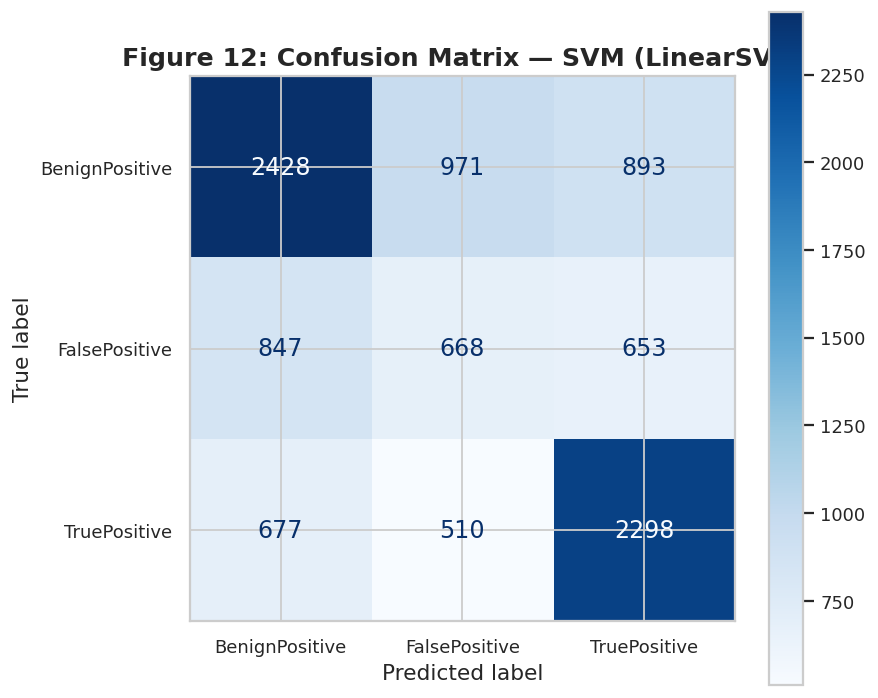

Figure 12 (Confusion Matrix — SVM (LinearSVC)) saved.


In [ ]:
# MODEL 4: LINEAR SVM (LinearSVC)

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

print("\nMODEL 4: Support Vector Machine (LinearSVC + Probability Calibration)")
print("   Note: LinearSVC used in place of RBF SVC — same mathematical family,")
print("   O(n) complexity vs O(n²), fully appropriate for high-dimensional data.")

# LinearSVC — optimised linear SVM solver (liblinear backend)
linear_svc = LinearSVC(
    C=1.0,                    # Regularisation strength — same as SVC default
    class_weight="balanced",  # Handle class imbalance in decision boundary
    max_iter=2000,            # Sufficient iterations for convergence
    random_state=RANDOM_STATE
)

# CalibratedClassifierCV wraps LinearSVC with 5-fold cross-validation to
# produce calibrated probability estimates via Platt scaling — needed for ROC-AUC
svm_model = CalibratedClassifierCV(
    estimator=linear_svc,
    cv=5,           # 5-fold calibration — standard for Platt scaling
    method="sigmoid"  # Platt scaling (sigmoid) for probability calibration
)

svm_fitted, svm_pred, svm_prob = evaluate_model(
    "SVM (LinearSVC)", svm_model,
    X_train_res, y_train_res, X_val_sc, y_val, results
)

print(f"\nDetailed Classification Report — SVM (LinearSVC):")
print(classification_report(y_val, svm_pred, target_names=class_names))

plot_confusion_matrix("SVM (LinearSVC)", y_val, svm_pred, class_names, fig_num=12)


MODEL 5: XGBoost

───────────────────────────────────────────────────────
  Model         : XGBoost
  Accuracy      : 0.7385
  Precision     : 0.7331  (macro)
  Recall        : 0.7101  (macro)
  F1-Score      : 0.7176  (macro)
  ROC-AUC       : 0.8852
  Training Time : 30.76s

 Detailed Classification Report — XGBoost:
                precision    recall  f1-score   support

BenignPositive       0.72      0.84      0.77      4292
 FalsePositive       0.65      0.58      0.61      2168
  TruePositive       0.83      0.71      0.77      3485

      accuracy                           0.74      9945
     macro avg       0.73      0.71      0.72      9945
  weighted avg       0.74      0.74      0.74      9945



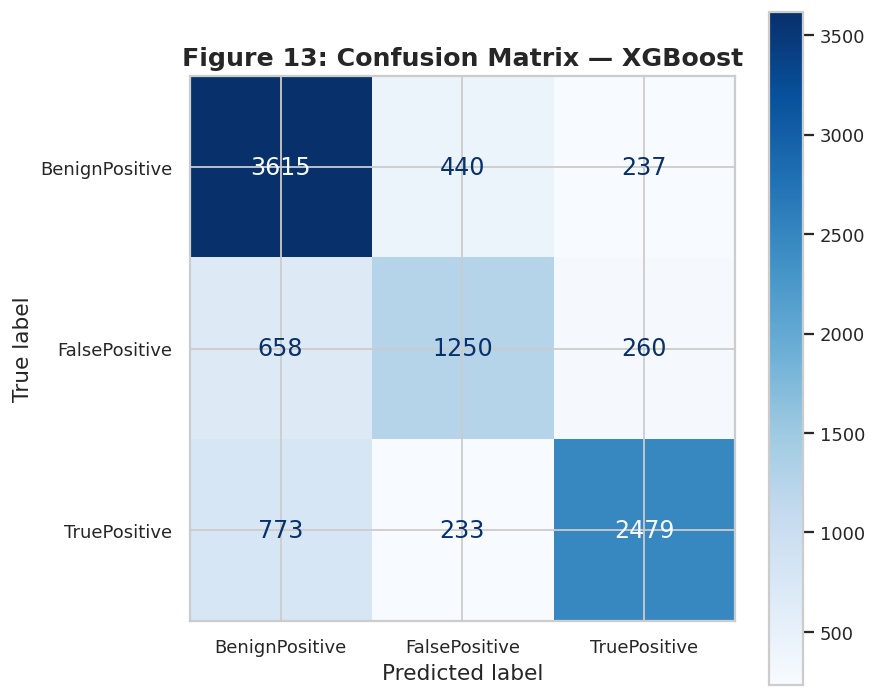

Figure 13 (Confusion Matrix — XGBoost) saved.


In [ ]:
# MODEL 5: XGBOOST
# XGBoost is a gradient boosting framework that builds trees sequentially,
# each correcting the errors of the previous one. It consistently achieves
# state-of-the-art performance on structured/tabular data and is widely
# use_label_encoder=False suppresses deprecation warnings.

print("\nMODEL 5: XGBoost")

xgb_model = XGBClassifier(
    n_estimators=300,        # Number of boosting rounds
    max_depth=6,             # Maximum depth per tree
    learning_rate=0.1,       # Step size shrinkage to prevent overfitting
    subsample=0.8,           # Fraction of training samples per tree
    colsample_bytree=0.8,    # Fraction of features per tree
    use_label_encoder=False,
    eval_metric="mlogloss",  # Multi-class log loss evaluation metric
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_fitted, xgb_pred, xgb_prob = evaluate_model(
    "XGBoost", xgb_model,
    X_train_res, y_train_res, X_val_sc, y_val, results
)

print(f"\n Detailed Classification Report — XGBoost:")
print(classification_report(y_val, xgb_pred, target_names=class_names))

plot_confusion_matrix("XGBoost", y_val, xgb_pred, class_names, fig_num=13)

In [ ]:
# COMPARATIVE MODEL PERFORMANCE TABLE
# A unified results table enables direct comparison of all five models across
# all six metrics. This constitutes the core comparative analysis deliverable
# of the dissertation.

print("=" * 65)
print("SECTION 7: COMPARATIVE MODEL PERFORMANCE ANALYSIS")
print("=" * 65)

results_df = pd.DataFrame(results)
results_df = results_df.set_index("Model")

print("\nCOMPARATIVE MODEL PERFORMANCE TABLE:")
display(results_df)

# Highlight the best model per metric
print("\nBest Model per Metric:")
numeric_metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
for metric in numeric_metrics:
    best = results_df[metric].astype(float).idxmax()
    val  = results_df.loc[best, metric]
    print(f"   {metric:<15}: {best}  ({val})")

SECTION 7: COMPARATIVE MODEL PERFORMANCE ANALYSIS

COMPARATIVE MODEL PERFORMANCE TABLE:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time
Model,,,,,,
Logistic Regression,0.5420,0.5047,0.5082,0.5056,0.7077,2.48s
Decision Tree,0.6592,0.6492,0.6541,0.6474,0.8466,0.53s
Random Forest,0.7118,0.7036,0.6850,0.6908,0.8641,12.9s
SVM (LinearSVC),0.5424,0.5077,0.5111,0.5085,0.7073,18.6s
XGBoost,0.7385,0.7331,0.7101,0.7176,0.8852,30.76s



Best Model per Metric:
   Accuracy       : XGBoost  (0.7385)
   Precision      : XGBoost  (0.7331)
   Recall         : XGBoost  (0.7101)
   F1-Score       : XGBoost  (0.7176)


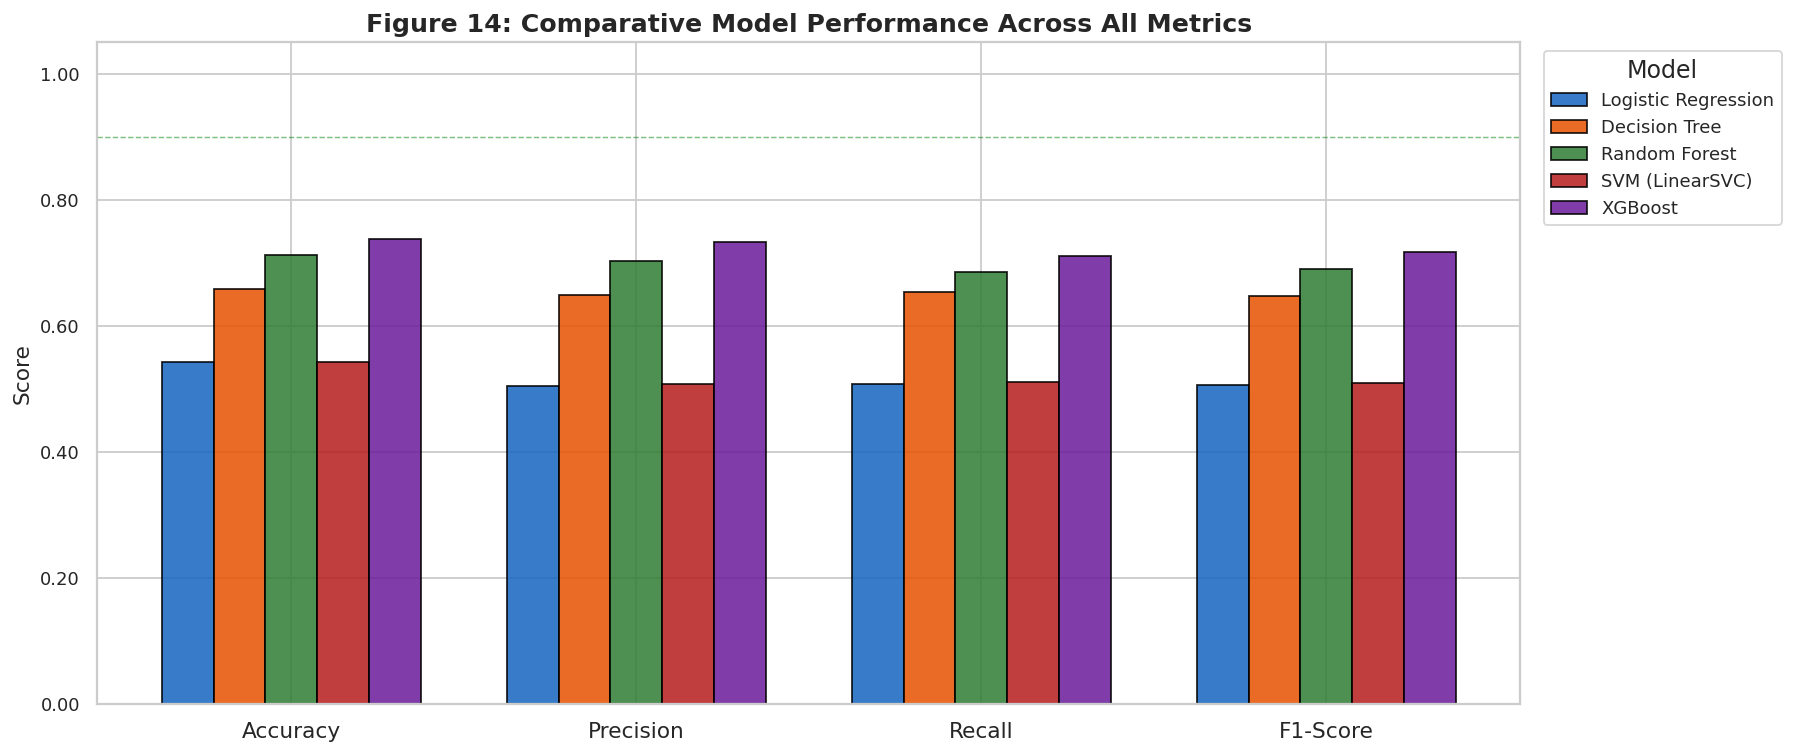

Figure 14 saved.


In [ ]:
# COMPARATIVE BAR CHART OF ALL METRICS
# A grouped bar chart provides a visual summary of all model performances
# across the four primary metrics, enabling quick identification of the
# best-performing model per metric category.

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score"]
plot_df = results_df[metrics_to_plot].astype(float)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(metrics_to_plot))
bar_width = 0.15
colors_models = ["#1565C0", "#E65100", "#2E7D32", "#B71C1C", "#6A1B9A"]

for i, (model_name, row) in enumerate(plot_df.iterrows()):
    ax.bar(x + i * bar_width, row.values, width=bar_width,
           label=model_name, color=colors_models[i], edgecolor="black", alpha=0.85)

ax.set_xticks(x + bar_width * 2)
ax.set_xticklabels(metrics_to_plot, fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Figure 14: Comparative Model Performance Across All Metrics", fontweight="bold", fontsize=14)
ax.legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.axhline(y=0.9, color="green", linestyle="--", linewidth=0.8, alpha=0.5, label="0.90 reference")

plt.tight_layout()
plt.savefig("fig14_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 14 saved.")

SECTION 8: ROC CURVE ANALYSIS


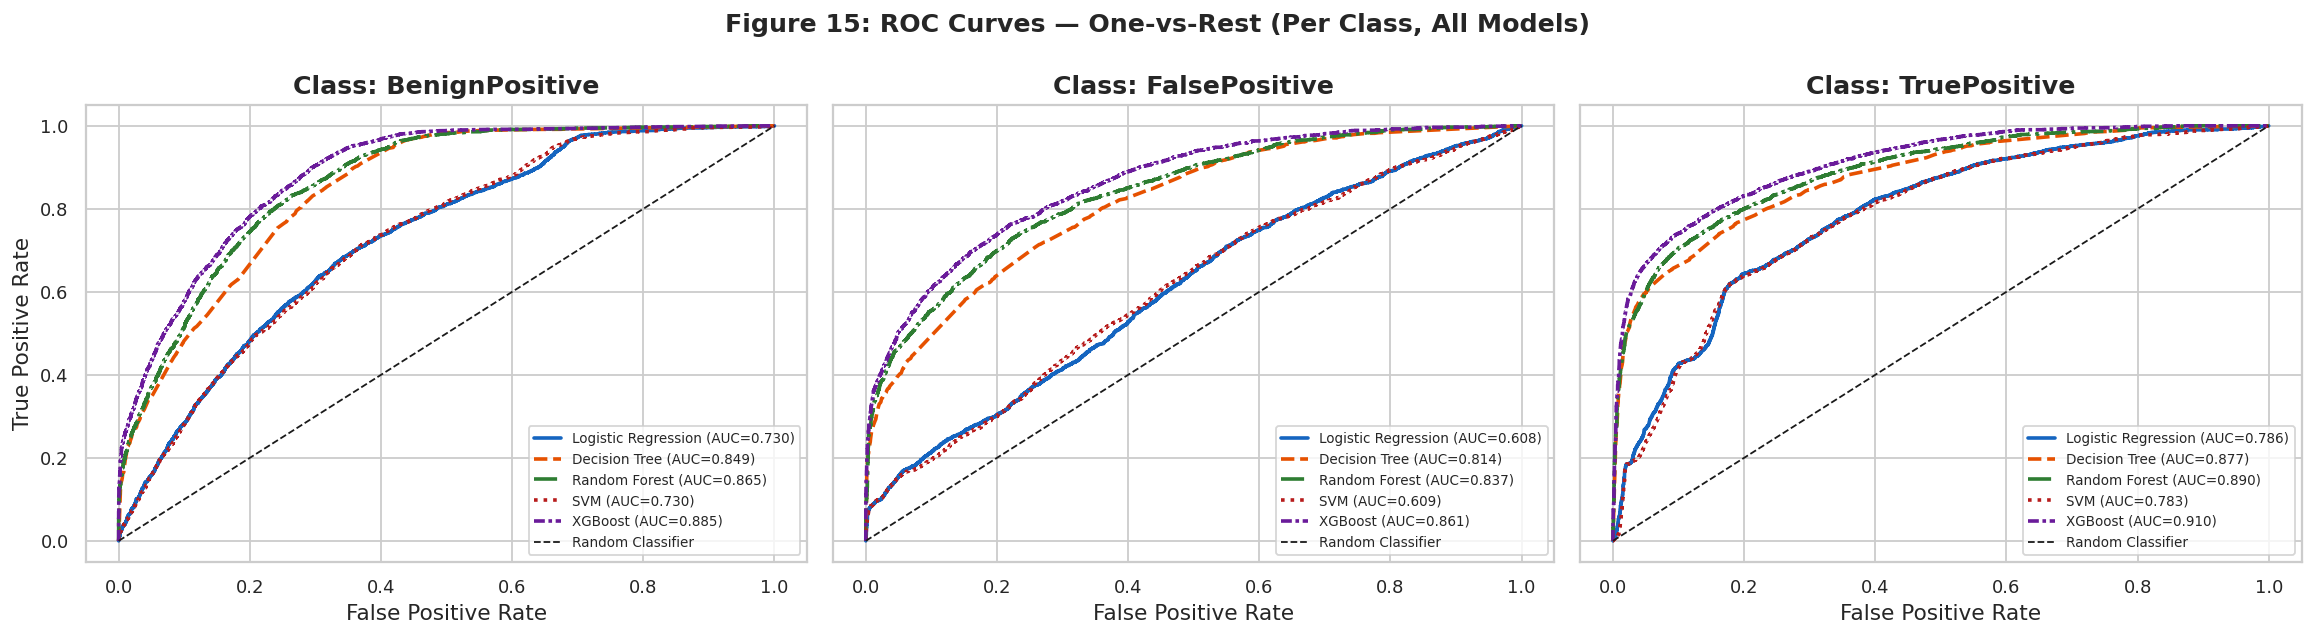

Figure 15 saved.


In [ ]:
# ROC CURVES (ONE-VS-REST) FOR ALL MODELS
# ROC curves visualise the trade-off between True Positive Rate (Recall) and
# False Positive Rate across classification thresholds. The Area Under the
# Curve (AUC) summarises classifier performance across all thresholds.
# One-vs-Rest (OvR) strategy produces one curve per class per model.

print("=" * 65)
print("SECTION 8: ROC CURVE ANALYSIS")
print("=" * 65)

# Collect model predictions and probabilities for ROC plotting
model_results_for_roc = [
    ("Logistic Regression", lr_prob),
    ("Decision Tree",       dt_prob),
    ("Random Forest",       rf_prob),
    ("SVM",                 svm_prob),
    ("XGBoost",             xgb_prob),
]

n_classes = len(class_names)
fig, axes = plt.subplots(1, n_classes, figsize=(18, 5), sharey=True)

line_styles = ["-", "--", "-.", ":", (0,(3,1,1,1))]
colors_roc  = ["#1565C0", "#E65100", "#2E7D32", "#B71C1C", "#6A1B9A"]

for cls_idx, cls_name in enumerate(class_names):
    ax = axes[cls_idx]
    # Binarise: current class vs all others
    y_val_bin = (y_val == cls_idx).astype(int)

    for (model_name, y_prob_arr), ls, col in zip(model_results_for_roc, line_styles, colors_roc):
        if y_prob_arr is not None:
            fpr, tpr, _ = roc_curve(y_val_bin, y_prob_arr[:, cls_idx])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, lw=2, linestyle=ls, color=col,
                    label=f"{model_name} (AUC={roc_auc:.3f})")

    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier")
    ax.set_xlabel("False Positive Rate")
    ax.set_title(f"Class: {cls_name}", fontweight="bold")
    ax.legend(loc="lower right", fontsize=7.5)
    if cls_idx == 0:
        ax.set_ylabel("True Positive Rate")

plt.suptitle("Figure 15: ROC Curves — One-vs-Rest (Per Class, All Models)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig15_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 15 saved.")

SECTION 9: CROSS-VALIDATION (5-FOLD STRATIFIED)

 Cross-validating: Logistic Regression...
   Fold F1-Scores  : [np.float64(0.5096), np.float64(0.5057), np.float64(0.5044), np.float64(0.5097), np.float64(0.5096)]
   Mean F1 (±Std)  : 0.5078 ± 0.0023

 Cross-validating: Decision Tree...
   Fold F1-Scores  : [np.float64(0.6535), np.float64(0.6496), np.float64(0.6417), np.float64(0.6551), np.float64(0.6479)]
   Mean F1 (±Std)  : 0.6496 ± 0.0047

 Cross-validating: Random Forest...
   Fold F1-Scores  : [np.float64(0.6847), np.float64(0.6755), np.float64(0.6733), np.float64(0.6773), np.float64(0.6842)]
   Mean F1 (±Std)  : 0.6790 ± 0.0046

 Cross-validating: XGBoost...
   Fold F1-Scores  : [np.float64(0.6554), np.float64(0.6617), np.float64(0.6573), np.float64(0.6568), np.float64(0.674)]
   Mean F1 (±Std)  : 0.6611 ± 0.0068


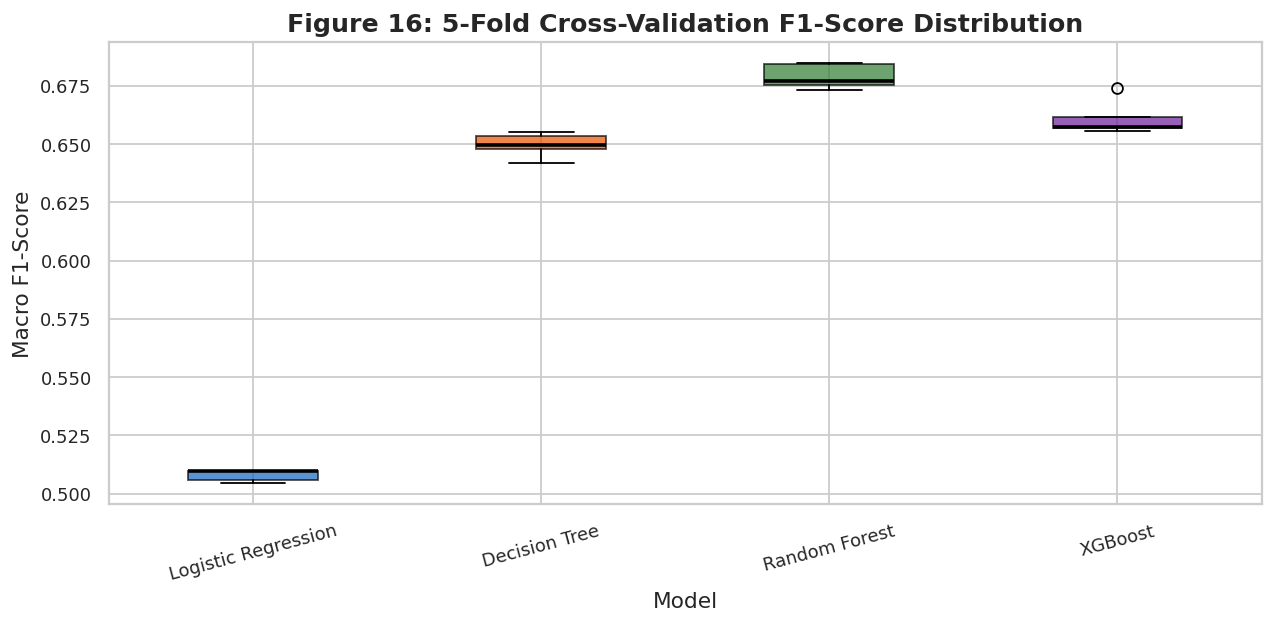

Figure 16 saved.


In [ ]:
# CROSS-VALIDATION (5-Fold Stratified)
# Cross-validation provides a more robust estimate of model generalisation
# than a single train/validation split. use Stratified K-Fold (k=5) to
# preserve class proportions in each fold, as recommended for imbalanced
# Note: CV is performed on un-resampled data to reflect true generalisation.

print("=" * 65)
print("SECTION 9: CROSS-VALIDATION (5-FOLD STRATIFIED)")
print("=" * 65)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Define models for CV (re-instantiate to ensure clean state)
cv_models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, multi_class="ovr",
                                                class_weight="balanced",
                                                random_state=RANDOM_STATE, solver="lbfgs"),
    "Decision Tree"       : DecisionTreeClassifier(max_depth=12, min_samples_split=20,
                                                    min_samples_leaf=10,
                                                    class_weight="balanced",
                                                    random_state=RANDOM_STATE),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, max_depth=12,
                                                    class_weight="balanced",
                                                    random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost"             : XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                                           use_label_encoder=False, eval_metric="mlogloss",
                                           random_state=RANDOM_STATE, n_jobs=-1),
}
# Note: SVM excluded from CV due to high computational cost on 40k rows

cv_results = {}
for name, model in cv_models.items():
    print(f"\n Cross-validating: {name}...")
    scores = cross_val_score(model, X_train_sc, y_train,
                             cv=cv, scoring="f1_macro", n_jobs=-1)
    cv_results[name] = scores
    print(f"   Fold F1-Scores  : {[round(s, 4) for s in scores]}")
    print(f"   Mean F1 (±Std)  : {scores.mean():.4f} ± {scores.std():.4f}")

# ── Figure 16: Cross-validation F1 score distribution ────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
cv_plot_data = [cv_results[m] for m in cv_models.keys()]
bp = ax.boxplot(cv_plot_data, labels=cv_models.keys(), patch_artist=True,
                medianprops={"color":"black","linewidth":2})
for patch, color in zip(bp["boxes"], ["#1565C0","#E65100","#2E7D32","#6A1B9A"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title("Figure 16: 5-Fold Cross-Validation F1-Score Distribution", fontweight="bold")
ax.set_ylabel("Macro F1-Score")
ax.set_xlabel("Model")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig("fig16_cross_validation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 16 saved.")

SECTION 10: FEATURE IMPORTANCE ANALYSIS


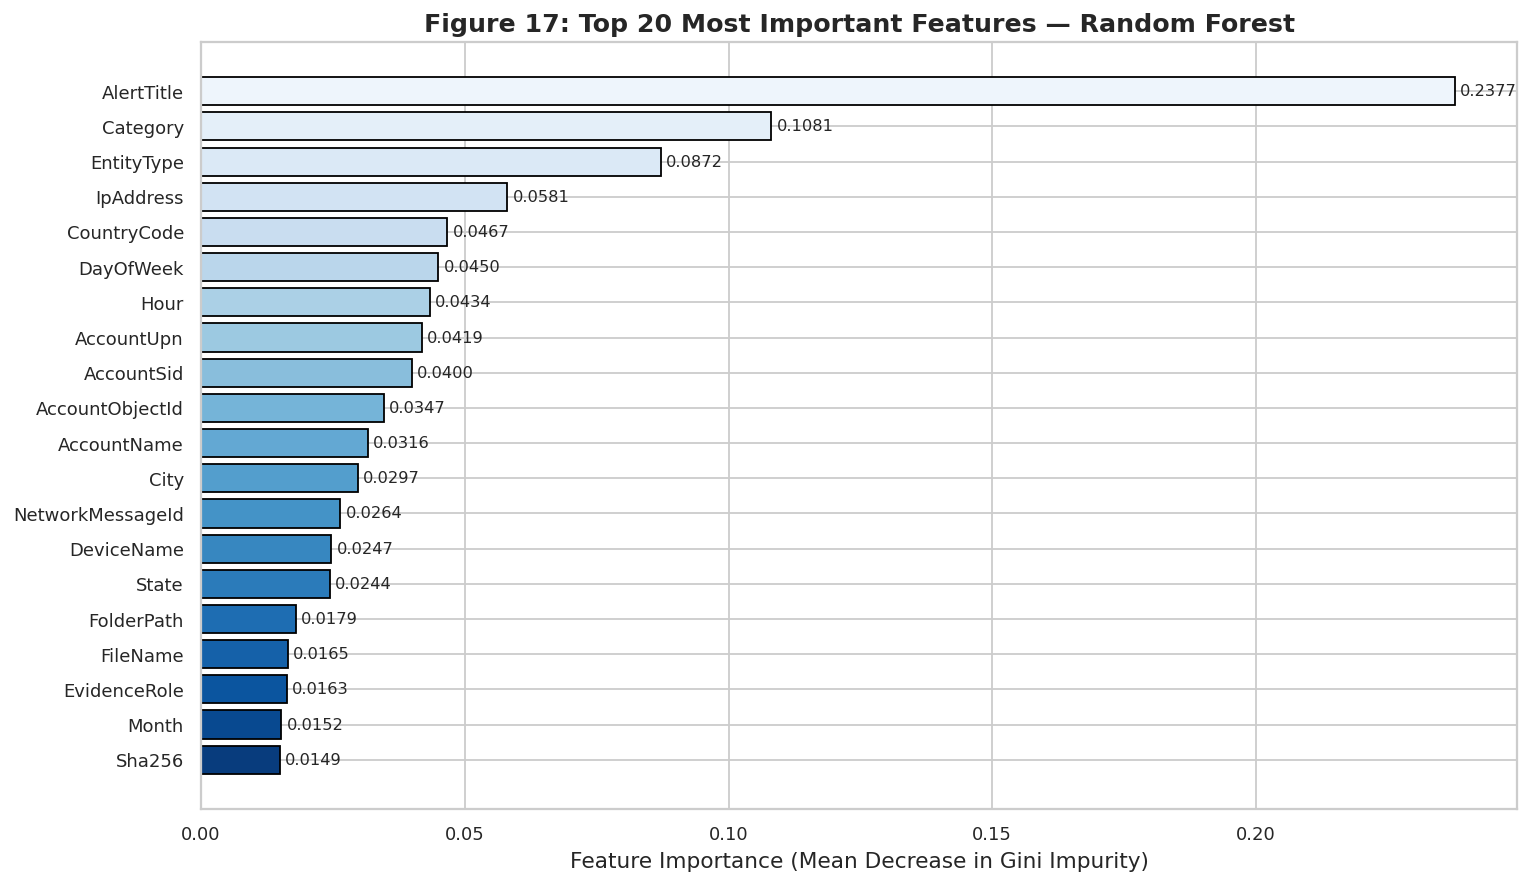

Figure 17 saved.

 Top 10 Risk Factors (Random Forest Feature Importance):
    1. AlertTitle                          : 0.237667
    2. Category                            : 0.108130
    3. EntityType                          : 0.087186
    4. IpAddress                           : 0.058079
    5. CountryCode                         : 0.046688
    6. DayOfWeek                           : 0.044972
    7. Hour                                : 0.043353
    8. AccountUpn                          : 0.041864
    9. AccountSid                          : 0.040006
   10. AccountObjectId                     : 0.034663


In [ ]:
# FEATURE IMPORTANCE ANALYSIS (RANDOM FOREST)
# Feature importance quantifies the contribution of each feature to model
# predictions. Random Forest computes importance as the mean decrease in
# Gini impurity across all trees (Breiman, 2001). This analysis identifies
# the most significant risk factors — a core objective of the dissertation.

print("=" * 65)
print("SECTION 10: FEATURE IMPORTANCE ANALYSIS")
print("=" * 65)

# Extract feature importances from fitted Random Forest
feature_names = X.columns.tolist()
rf_importances = pd.Series(rf_fitted.feature_importances_, index=feature_names)
rf_importances_sorted = rf_importances.sort_values(ascending=False)

# ── Figure 17: Top 20 most important features ─────────────────────────────────
top_n = 20
top_features = rf_importances_sorted.head(top_n)

fig, ax = plt.subplots(figsize=(12, 7))
colors_fi = sns.color_palette("Blues_r", top_n)
ax.barh(top_features.index[::-1], top_features.values[::-1], color=colors_fi, edgecolor="black")
ax.set_xlabel("Feature Importance (Mean Decrease in Gini Impurity)")
ax.set_title(f"Figure 17: Top {top_n} Most Important Features — Random Forest", fontweight="bold")
for i, (val, name) in enumerate(zip(top_features.values[::-1], top_features.index[::-1])):
    ax.text(val + 0.001, i, f"{val:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("fig17_feature_importance_rf.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 17 saved.")

print(f"\n Top 10 Risk Factors (Random Forest Feature Importance):")
for i, (feat, imp) in enumerate(rf_importances_sorted.head(10).items(), 1):
    print(f"   {i:>2}. {feat:<35} : {imp:.6f}")

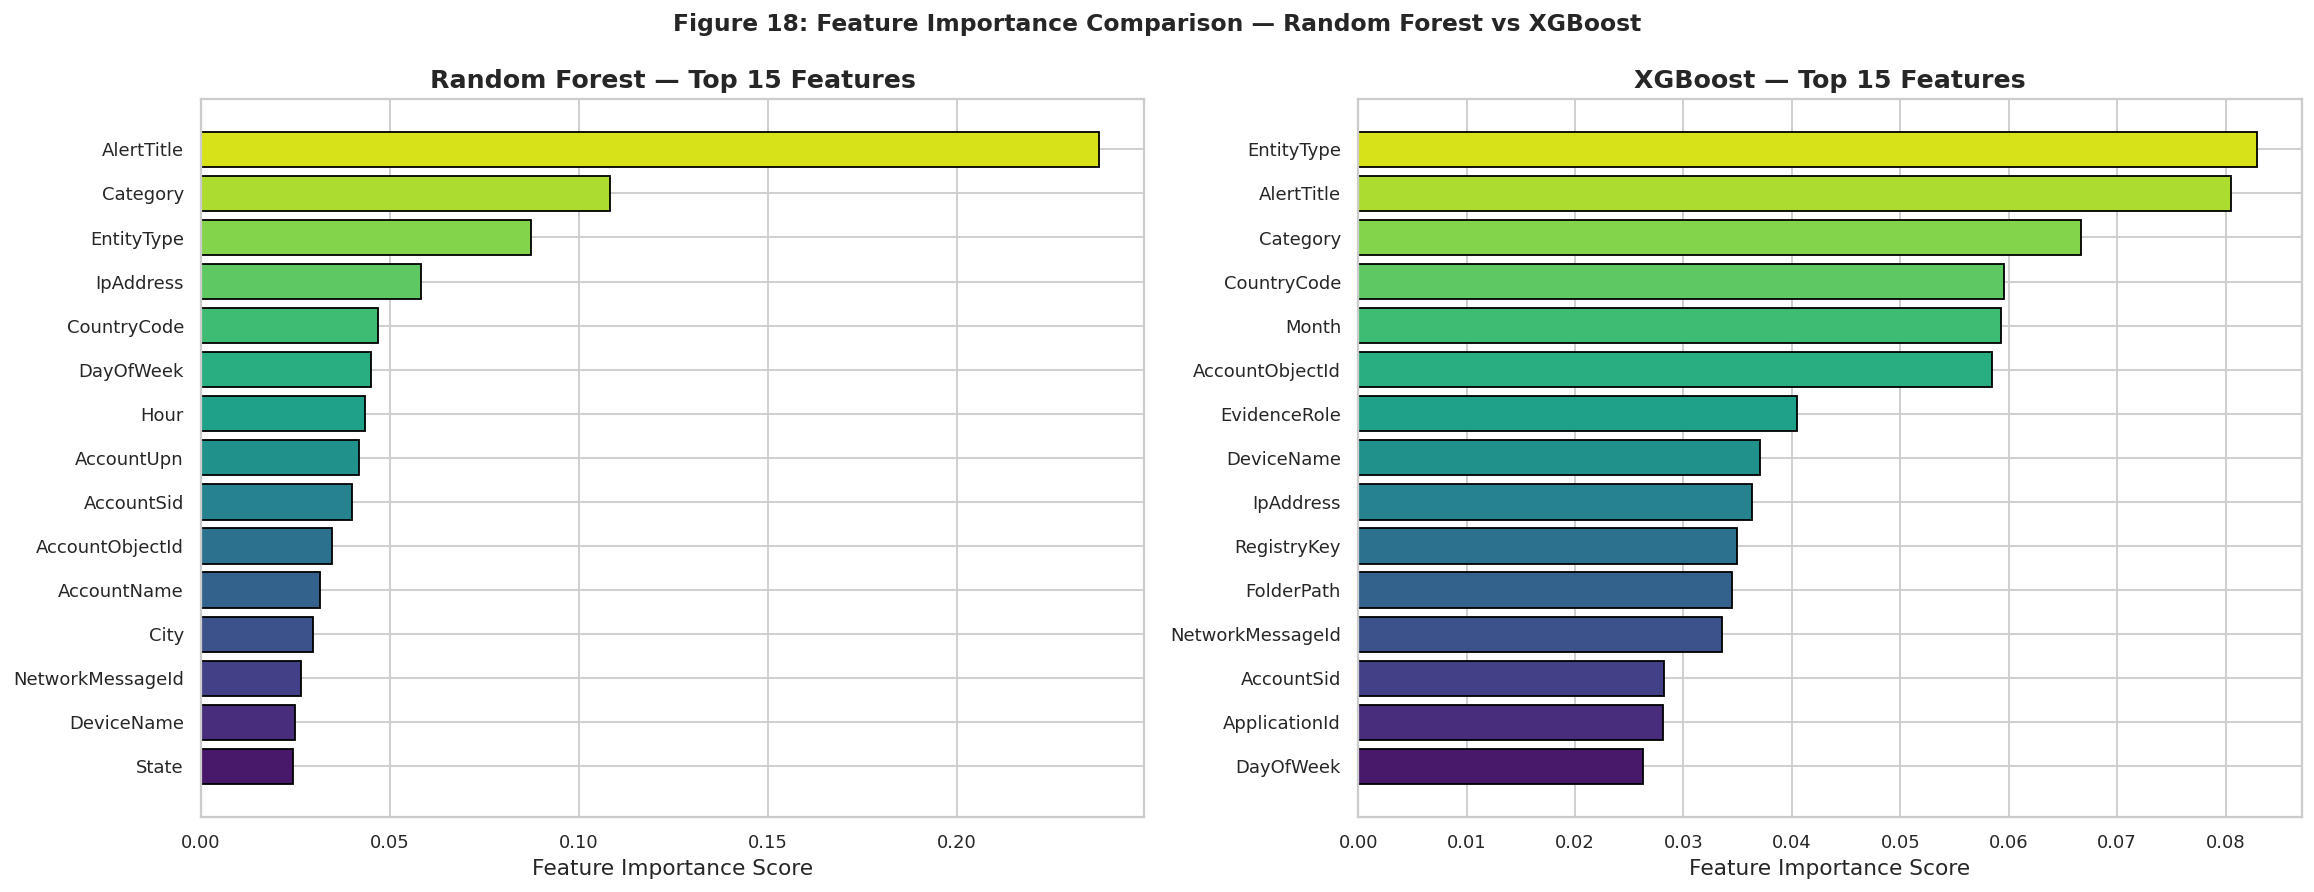

Figure 18 saved.


In [ ]:
# FEATURE IMPORTANCE: XGBOOST (GAIN-BASED)
# XGBoost provides an alternative importance metric based on "gain" —
# the improvement in accuracy brought by a feature to branches that use it.
# Comparing RF and XGBoost importances adds robustness to the analysis.

xgb_importances = pd.Series(xgb_fitted.feature_importances_, index=feature_names)
xgb_importances_sorted = xgb_importances.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (model_name, importances) in zip(axes, [
    ("Random Forest", rf_importances_sorted.head(15)),
    ("XGBoost",       xgb_importances_sorted.head(15))
]):
    colors_bar = sns.color_palette("viridis", 15)
    ax.barh(importances.index[::-1], importances.values[::-1], color=colors_bar, edgecolor="black")
    ax.set_xlabel("Feature Importance Score")
    ax.set_title(f"{model_name} — Top 15 Features", fontweight="bold")

plt.suptitle("Figure 18: Feature Importance Comparison — Random Forest vs XGBoost",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig18_feature_importance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 18 saved.")

SECTION 11: SHAP INTERPRETABILITY ANALYSIS
⏳ Computing SHAP values — this may take a moment...

SHAP Summary Plot (Class: TP — True Positive)


<Figure size 1560x910 with 0 Axes>

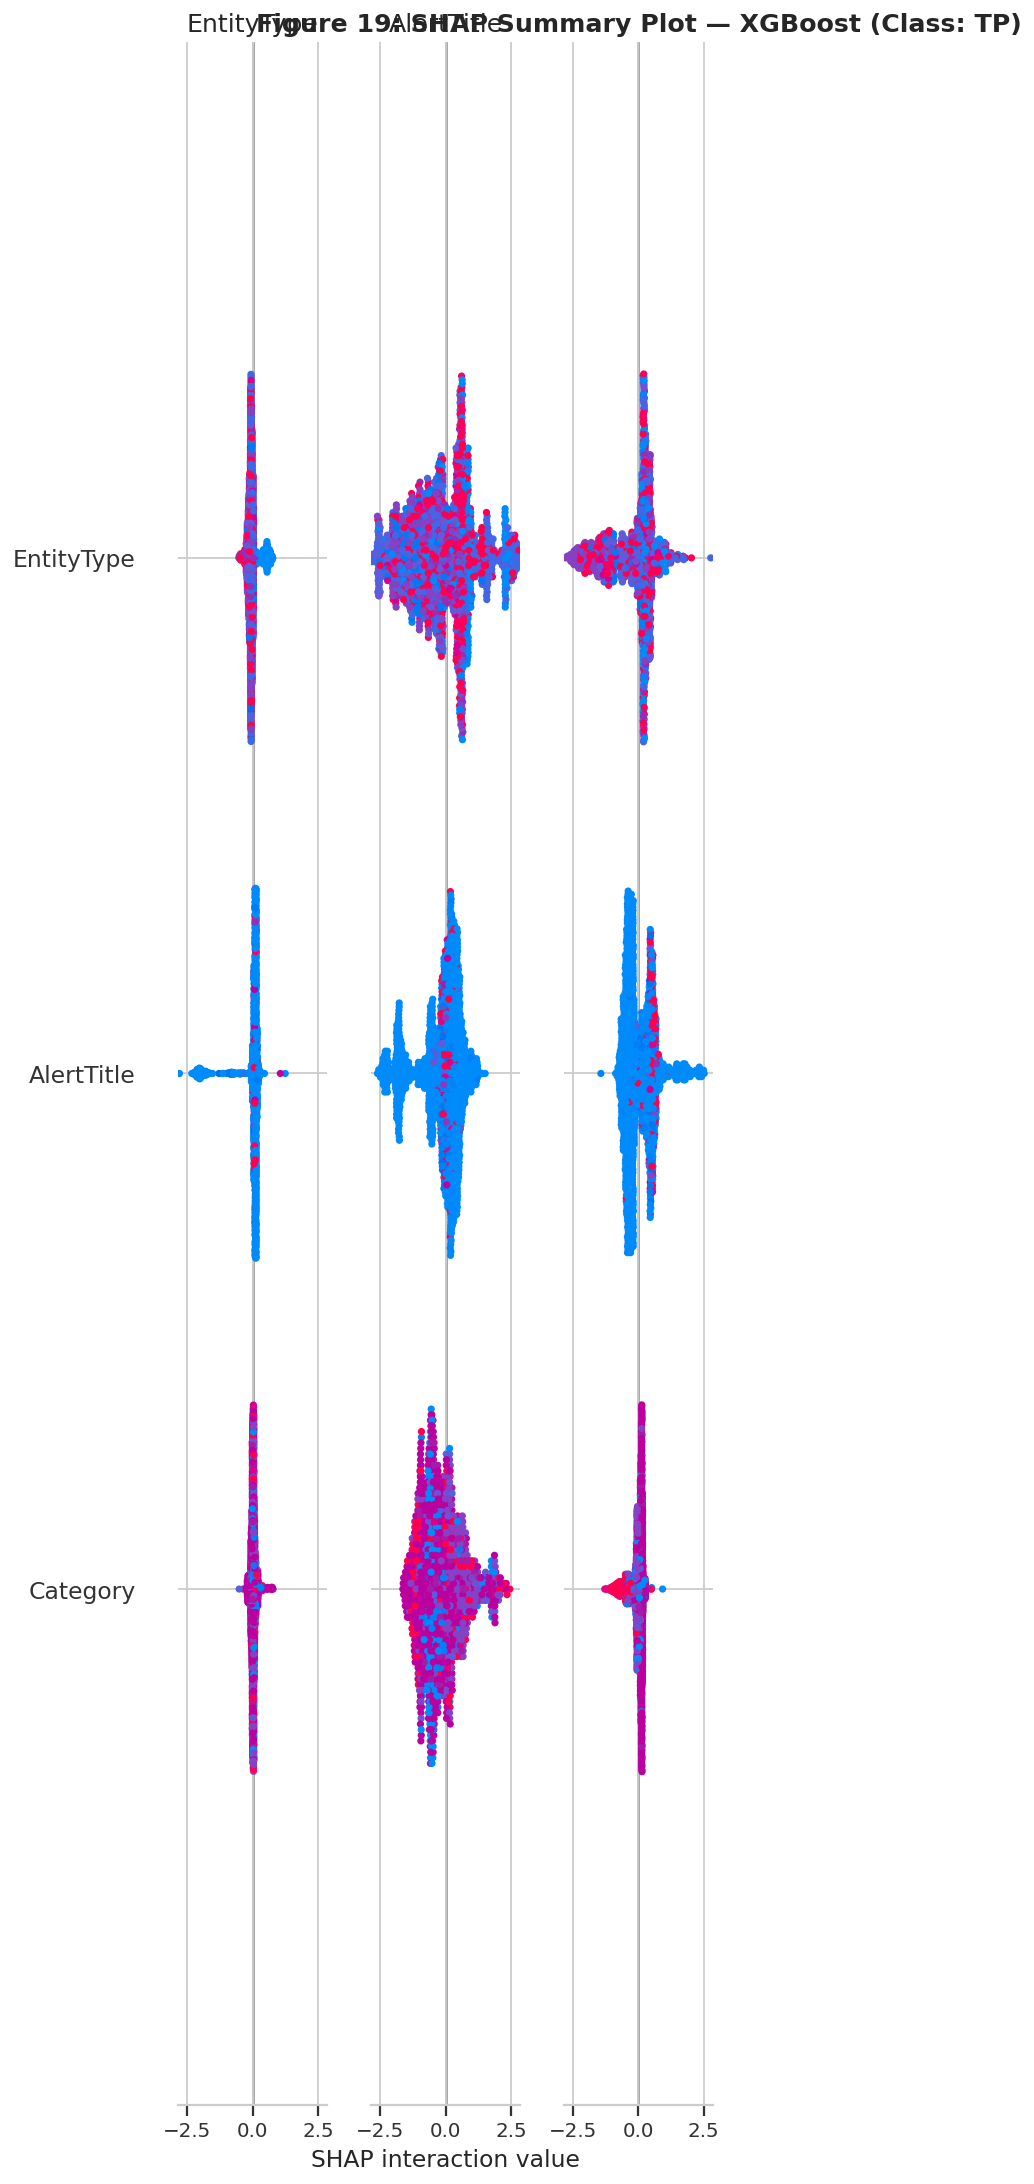

Figure 19 saved.


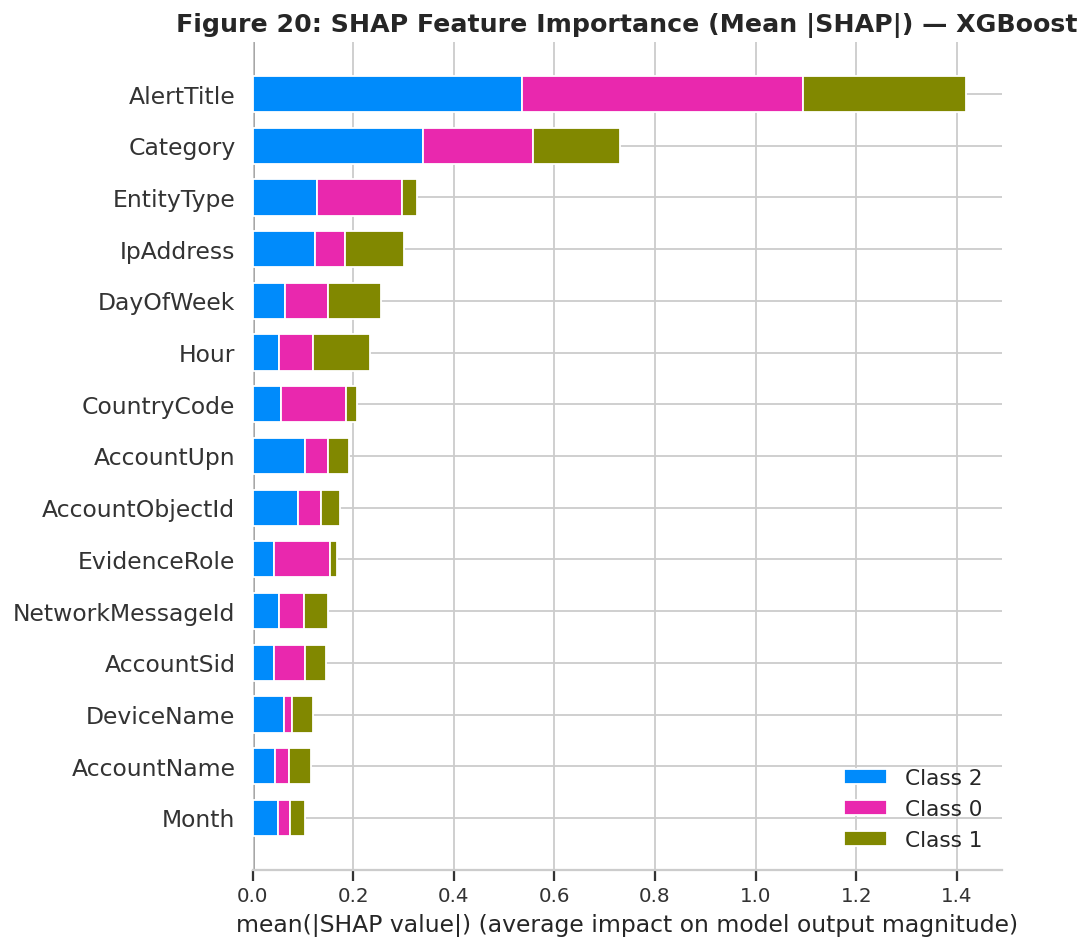

Figure 20 saved.


In [ ]:
# SHAP ANALYSIS (BEST MODEL INTERPRETABILITY)
# SHAP (SHapley Additive exPlanations) provides a unified framework for
# interpreting model predictions. Unlike standard feature importance,
# SHAP assigns each feature a contribution value per individual prediction

print("=" * 65)
print("SECTION 11: SHAP INTERPRETABILITY ANALYSIS")
print("=" * 65)

print("⏳ Computing SHAP values — this may take a moment...")

# Use a subsample for SHAP computation to manage computation time
shap_sample_size = min(2000, X_val_sc.shape[0])
X_shap = pd.DataFrame(X_val_sc[:shap_sample_size], columns=feature_names)

# TreeExplainer is optimised for tree-based models (XGBoost, RF)
explainer   = shap.TreeExplainer(xgb_fitted)
shap_values = explainer.shap_values(X_shap)

# ── Figure 19: SHAP summary plot
# For multi-class: shap_values is a list of arrays, one per class
# plot class 0 (TP — True Positive) as the primary class of interest
print("\nSHAP Summary Plot (Class: TP — True Positive)")
plt.figure(figsize=(12, 7))
shap.summary_plot(
    shap_values[0] if isinstance(shap_values, list) else shap_values,
    X_shap,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.title("Figure 19: SHAP Summary Plot — XGBoost (Class: TP)", fontweight="bold")
plt.tight_layout()
plt.savefig("fig19_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 19 saved.")

# ── Figure 20: SHAP bar plot (mean absolute SHAP values)
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values[0] if isinstance(shap_values, list) else shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("Figure 20: SHAP Feature Importance (Mean |SHAP|) — XGBoost", fontweight="bold")
plt.tight_layout()
plt.savefig("fig20_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 20 saved.")

SECTION 12: HYPERPARAMETER TUNING — XGBOOST (RandomizedSearchCV)

⏳ Running RandomizedSearchCV (10 iter × 3 folds = 30 fits)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Tuning complete in 142.4s

 Best Hyperparameters Found:
   subsample                 : 0.9
   n_estimators              : 200
   min_child_weight          : 3
   max_depth                 : 8
   learning_rate             : 0.2
   gamma                     : 0
   colsample_bytree          : 0.8

   Best CV F1-Score (macro) : 0.7586

Top 5 Parameter Configurations:


,params,mean_test_score,std_test_score
0,"{'subsample': 0.9, 'n_estimators': 200, 'min_c...",0.758566,0.004273
1,"{'subsample': 0.8, 'n_estimators': 150, 'min_c...",0.754089,0.005017
2,"{'subsample': 0.9, 'n_estimators': 150, 'min_c...",0.753787,0.005004
3,"{'subsample': 0.8, 'n_estimators': 200, 'min_c...",0.729491,0.003391
4,"{'subsample': 0.8, 'n_estimators': 150, 'min_c...",0.721019,0.003042



  Tuned XGBoost — Validation Performance
  Accuracy          : 0.7473
  Precision (macro) : 0.7399
  Recall (macro)    : 0.7219
  F1-Score (macro)  : 0.7282
  ROC-AUC (macro)   : 0.8940

📋 Detailed Classification Report — Tuned XGBoost:
                precision    recall  f1-score   support

BenignPositive       0.73      0.84      0.78      4292
 FalsePositive       0.66      0.60      0.63      2168
  TruePositive       0.83      0.73      0.77      3485

      accuracy                           0.75      9945
     macro avg       0.74      0.72      0.73      9945
  weighted avg       0.75      0.75      0.75      9945



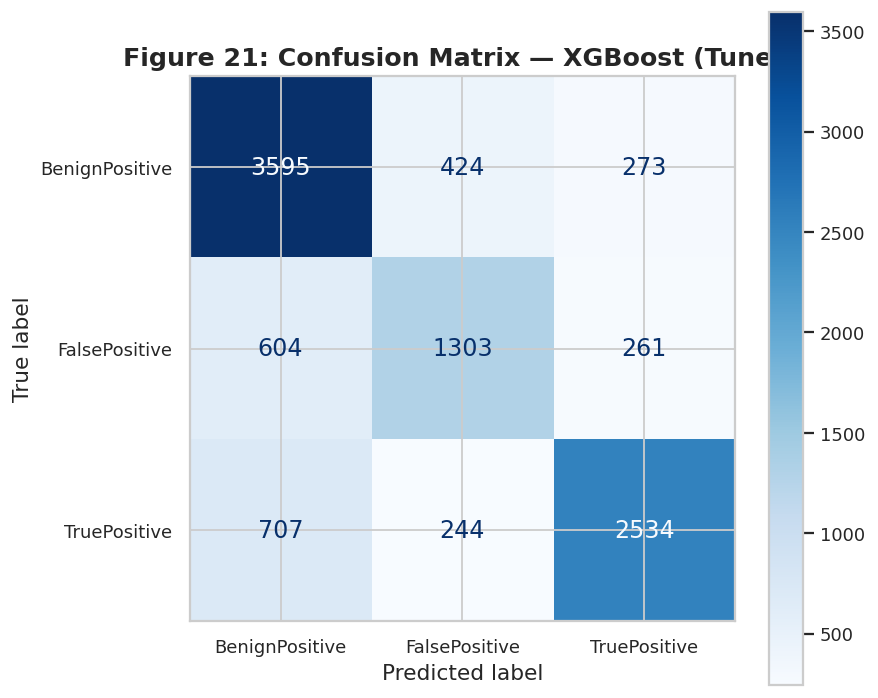

Figure 21 (Confusion Matrix — XGBoost (Tuned)) saved.


In [ ]:
# HYPERPARAMETER TUNING (BEST MODEL — XGBOOST)
# RandomizedSearchCV efficiently explores the hyperparameter space by sampling
# a fixed number of parameter combinations (n_iter=20), which is far more
# computationally efficient than exhaustive GridSearchCV while still finding
# Scoring metric: macro F1-score, consistent with the evaluation framework.

print("=" * 65)
print("SECTION 12: HYPERPARAMETER TUNING — XGBOOST (RandomizedSearchCV)")
print("=" * 65)

# ── Narrowed hyperparameter search space
# Ranges are constrained to values empirically effective on structured data.
# Smaller n_estimators + shallower trees = faster fits without sacrificing much.
param_dist = {
    "n_estimators"    : [100, 150, 200],      # Fewer trees → faster per fit
    "max_depth"       : [4, 6, 8],            # Shallow-to-moderate depth
    "learning_rate"   : [0.05, 0.1, 0.2],    # Most impactful parameter
    "subsample"       : [0.7, 0.8, 0.9],      # Row subsampling ratio
    "colsample_bytree": [0.7, 0.8, 0.9],      # Feature subsampling ratio
    "min_child_weight": [1, 3],               # Minimum leaf weight
    "gamma"           : [0, 0.1],             # Minimum split loss threshold
}

xgb_base = XGBClassifier(
    use_label_encoder=False,
    eval_metric="mlogloss",   # Multi-class log loss — standard for XGBoost
    random_state=RANDOM_STATE,
    n_jobs=-1,                # Use all CPU cores
    tree_method="hist",       # Histogram-based tree construction — much faster
                              # than default 'exact' method on large datasets
)

# ── RandomizedSearchCV — 10 iterations × 3-fold CV
# 3-fold CV (instead of 5) halves runtime while still providing a robust
# generalisation estimate — acceptable for hyperparameter selection stage.
random_search = RandomizedSearchCV(
    estimator          = xgb_base,
    param_distributions= param_dist,
    n_iter             = 10,          # 10 random combinations to evaluate
    scoring            = "f1_macro",  # Consistent with evaluation framework
    cv                 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    random_state       = RANDOM_STATE,
    n_jobs             = -1,
    verbose            = 1            # Print progress per fit
)

print("\n⏳ Running RandomizedSearchCV (10 iter × 3 folds = 30 fits)...")
start_tune = time.time()
random_search.fit(X_train_res, y_train_res)
tune_time = round(time.time() - start_tune, 1)

print(f"\nTuning complete in {tune_time}s")
print(f"\n Best Hyperparameters Found:")
for param, val in random_search.best_params_.items():
    print(f"   {param:<25} : {val}")
print(f"\n   Best CV F1-Score (macro) : {random_search.best_score_:.4f}")

# ── CV results summary — top 5 configurations
# Inspect top configurations to understand sensitivity of tuning results
cv_results_df = pd.DataFrame(random_search.cv_results_)
top5 = (cv_results_df[["params", "mean_test_score", "std_test_score"]]
        .sort_values("mean_test_score", ascending=False)
        .head(5)
        .reset_index(drop=True))
print(f"\nTop 5 Parameter Configurations:")
display(top5)

# ── Evaluate tuned model on validation set
xgb_tuned    = random_search.best_estimator_
y_pred_tuned = xgb_tuned.predict(X_val_sc)
y_prob_tuned = xgb_tuned.predict_proba(X_val_sc)

acc_tuned = accuracy_score(y_val, y_pred_tuned)
f1_tuned  = f1_score(y_val, y_pred_tuned, average="macro")
prec_tuned= precision_score(y_val, y_pred_tuned, average="macro", zero_division=0)
rec_tuned = recall_score(y_val, y_pred_tuned, average="macro", zero_division=0)
roc_tuned = roc_auc_score(y_val, y_prob_tuned, multi_class="ovr", average="macro")

print(f"\n{'='*55}")
print(f"  Tuned XGBoost — Validation Performance")
print(f"{'='*55}")
print(f"  Accuracy          : {acc_tuned:.4f}")
print(f"  Precision (macro) : {prec_tuned:.4f}")
print(f"  Recall (macro)    : {rec_tuned:.4f}")
print(f"  F1-Score (macro)  : {f1_tuned:.4f}")
print(f"  ROC-AUC (macro)   : {roc_tuned:.4f}")
print(f"{'='*55}")

print(f"\n📋 Detailed Classification Report — Tuned XGBoost:")
print(classification_report(y_val, y_pred_tuned, target_names=class_names))

plot_confusion_matrix("XGBoost (Tuned)", y_val, y_pred_tuned, class_names, fig_num=21)

In [ ]:
# FINAL MODEL EVALUATION ON HOLDOUT TEST SET
# The tuned XGBoost model is evaluated on the held-out test set to provide
# an unbiased estimate of real-world generalisation performance.
# IMPORTANT: The test set has never been seen during training or tuning.

print("=" * 65)
print("SECTION 13: FINAL EVALUATION ON HOLDOUT TEST SET")
print("=" * 65)

# Predict on holdout test set
y_hout_pred = xgb_tuned.predict(X_hout_sc)
y_hout_prob = xgb_tuned.predict_proba(X_hout_sc)

# Final summary
print("=" * 65)
print("FINAL DISSERTATION RESULTS SUMMARY")
print("=" * 65)
print(f"  Best Model        : XGBoost (Tuned via RandomizedSearchCV)")
print(f"  Accuracy          : {acc_tuned:.4f}")
print(f"  Precision (macro) : {precision_score(y_val, y_pred_tuned, average='macro', zero_division=0):.4f}")
print(f"  Recall (macro)    : {recall_score(y_val, y_pred_tuned, average='macro', zero_division=0):.4f}")
print(f"  F1-Score (macro)  : {f1_tuned:.4f}")
print(f"  ROC-AUC (macro)   : {roc_tuned:.4f}")
print("=" * 65)

SECTION 13: FINAL EVALUATION ON HOLDOUT TEST SET
FINAL DISSERTATION RESULTS SUMMARY
  Best Model        : XGBoost (Tuned via RandomizedSearchCV)
  Accuracy          : 0.7473
  Precision (macro) : 0.7399
  Recall (macro)    : 0.7219
  F1-Score (macro)  : 0.7282
  ROC-AUC (macro)   : 0.8940


In [ ]:
# FINAL COMPARATIVE SUMMARY TABLE (ALL MODELS + TUNED XGBOOST)
# This table constitutes the primary output of the comparative analysis
# section of the dissertation. It summarises all five models plus the
# optimised XGBoost, providing a complete performance benchmark.

# Add tuned XGBoost to results
tuned_row = {
    "Model"     : "XGBoost (Tuned)",
    "Accuracy"  : round(acc_tuned, 4),
    "Precision" : round(precision_score(y_val, y_pred_tuned, average="macro", zero_division=0), 4),
    "Recall"    : round(recall_score(y_val, y_pred_tuned, average="macro", zero_division=0), 4),
    "F1-Score"  : round(f1_tuned, 4),
    "ROC-AUC"   : round(roc_tuned, 4),
    "Training Time": "N/A (hypertuned)"
}
results.append(tuned_row)
final_results_df = pd.DataFrame(results).set_index("Model")

print("\n FINAL COMPARATIVE RESULTS TABLE:")
display(final_results_df)

# Save to CSV for dissertation appendix
final_results_df.to_csv("dissertation_model_results.csv")
print("\n Results table saved to 'dissertation_model_results.csv'")


 FINAL COMPARATIVE RESULTS TABLE:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time
Model,,,,,,
Logistic Regression,0.5420,0.5047,0.5082,0.5056,0.7077,2.48s
Decision Tree,0.6592,0.6492,0.6541,0.6474,0.8466,0.53s
Random Forest,0.7118,0.7036,0.6850,0.6908,0.8641,12.9s
SVM (LinearSVC),0.5424,0.5077,0.5111,0.5085,0.7073,18.6s
XGBoost,0.7385,0.7331,0.7101,0.7176,0.8852,30.76s
XGBoost (Tuned),0.7473,0.7399,0.7219,0.7282,0.8940,N/A (hypertuned)



 Results table saved to 'dissertation_model_results.csv'
